---

**Author**: Imene DERRAR &nbsp;·&nbsp; **Supervisor**: Abdelillah OTMANE CHERIF  
**Institutions**: NHSM — National Higher School of Mathematics &nbsp;·&nbsp; IHFR — Institut Hydrométéorologique de Formation et de Recherche  
**Academic year**: 2025–2026  
**Project**: Final-year engineering thesis in Applied Mathematics — Drought modelling and probabilistic forecasting for the Chélif basin

---

<!-- thesis-provenance-v1 -->
# Notebook E.4 --- SPI construction and Kolmogorov--Smirnov validation

**Thesis support.** Chapter 3 (Data Engineering and Index Construction), §3.8--§3.10

**Purpose.** Computes SPI at three accumulation scales (3, 6, 12 months) by per-station / per-calendar-month maximum-likelihood Gamma fitting, mixed-distribution zero handling, and probit transformation. Validates the resulting indices through moment checks (mean ~0, std ~1), Kolmogorov--Smirnov goodness-of-fit at the 5% level, and pooled drought-class frequency reporting.

**Main inputs.** SPI-ready dataset from notebook E.3.

**Main outputs.** Station-level SPI-3/6/12 series; Gamma parameter table (324 fits); KS validation table; pooled drought-class frequency table. Referenced as Tables 3.7--3.9 and Figures 3.x in the thesis.

**Dependencies.** Requires notebook E.3 to have been run first.

**Execution notes.** All code cells in this notebook have been executed and their outputs (figures, tables, diagnostics) are saved inline. A re-run from a clean kernel should reproduce these outputs given the same input data, with the caveats listed in Appendix B of the thesis (reproducibility and computational environment).

# notebook E.4 — SPI Construction and Validation

**Thesis:** Drought Modeling and Probabilistic Forecasting in the Chélif Basin (Algeria)
**Input:** SPI-ready dataset produced by notebook E.3 (`spi_ready_dataset.csv`)
**Output:** Station-level and regional SPI series with full validation diagnostics

---

## Mathematical framework

The Standardized Precipitation Index (McKee et al., 1993) transforms a monthly
precipitation record into a standardised anomaly through the following pipeline:

**Step 1 — Accumulate precipitation over scale $k$:**

$$X_t^{(k)} = \sum_{i=0}^{k-1} P_{t-i}$$

**Step 2 — Separate by calendar month.** The accumulated series is partitioned
into 12 sub-series, one per calendar month (January, February, …). Each
sub-series is treated as an independent sample. This step is mandatory because
precipitation distributions are highly seasonal — fitting a single annual
distribution would pool incommensurable months and produce meaningless
standardised values.

**Step 3 — Fit a Gamma distribution to positive accumulations.** For each
station $i$, scale $k$, and calendar month $m$, the two-parameter Gamma
distribution is fitted to the strictly positive subset of the accumulation
sample using Maximum Likelihood Estimation (MLE) with location fixed at zero.

**Step 4 — Handle zero precipitation.** Since accumulated precipitation may
contain zero values, the distribution is treated as a mixed distribution
composed of a point mass at zero and a continuous Gamma component on positive
values. The empirical zero probability $\hat{q}$ is estimated from the sample,
and the mixed CDF is:
$$H(x) = \hat{q} + (1-\hat{q})\, G(x;\,\hat{\alpha},\hat{\beta}), \qquad x > 0$$
$$H(0) = \hat{q}$$

**Step 5 — Transform to standard normal.** The mixed CDF value is mapped to
the standard normal scale via the probit (quantile) function:
$$\text{SPI} = \Phi^{-1}(H(x))$$

If $H(x)$ were the exact CDF of the data, the resulting SPI values would be
exactly $\mathcal{N}(0,1)$. In practice, finite-sample deviations remain.

---

### Gamma parameterisation and estimation

The two-parameter Gamma distribution has PDF:
$$f(x;\,\alpha,\beta) = \frac{x^{\alpha-1}e^{-x/\beta}}{\beta^\alpha \Gamma(\alpha)},
\qquad x > 0,\; \alpha > 0,\; \beta > 0$$

where $\alpha$ is the **shape** parameter and $\beta$ is the **scale** parameter.

> Parameters are estimated by **Maximum Likelihood Estimation** applied to the
> strictly positive accumulation values, with the location parameter fixed at
> zero (`floc=0`), consistent with the physical constraint $X \geq 0$ and the
> classical SPI framework (McKee et al., 1993; Lloyd-Hughes & Saunders, 2002).

---

### Numerical stability

To avoid $\pm\infty$ in the probit transform, cumulative probabilities are
clipped to a small open interval $(\varepsilon, 1-\varepsilon)$ before
applying $\Phi^{-1}$:

$$H \leftarrow \text{clip}(H,\; 10^{-6},\; 1-10^{-6})$$

---

**What this notebook does:**
- Compute SPI-3, SPI-6, and SPI-12 for all 9 retained stations
- Fit 9 × 12 = 108 station-month Gamma distributions per scale, with sample-size
  diagnostics and variance safeguards
- Validate convergence to $\mathcal{N}(0,1)$ statistically and visually
- Quantify sensitivity to the 1.08 % of interpolated values inherited from notebook E.3
- Compute and validate a spatially averaged regional SPI series

**What this notebook does NOT do:**
- Use any black-box SPI library (all steps are implemented from statistical theory)
- Fit a single distribution across all months
- Ignore zero precipitation months

---

## Section 0 — Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.stats import gamma as gamma_dist, norm, kstest, shapiro

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.width", 130)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── Notebook identity ─────────────────────────────────────────────────────────
NOTEBOOK_NAME = "02_spi_construction_and_validation"

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR    = Path(os.environ.get("CHELIF_BASE_DIR", Path.cwd()))
INPUT_DIR   = BASE_DIR / "03_outputs" / "01_data_preprocessing_and_station_selection"
OUTPUT_DIR  = BASE_DIR / "03_outputs" / NOTEBOOK_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Column names ──────────────────────────────────────────────────────────────
STATION_COL = "master_station_id"
DATE_COL    = "date"
PRECIP_COL  = "precip_filled"    # gap-filled column produced by notebook E.3
RAW_COL     = "precip_mm"        # raw column retained for sensitivity analysis
INTERP_COL  = "was_interpolated"

# ── SPI configuration ─────────────────────────────────────────────────────────
SPI_SCALES = [3, 6, 12]

# ── Fitting sample-size thresholds ───────────────────────────────────────────
# MIN_OBS_PER_MONTH: minimum total (incl. zeros) accumulations per calendar-month
# subgroup before any fitting is attempted. WMO / Stagge et al. (2015) recommend
# ≥ 30; we use 20 as a lower-bound given the 26-year record.
MIN_OBS_PER_MONTH = 20

# MIN_FIT_N: minimum strictly positive values required for Gamma MLE.
MIN_FIT_N  = 4

# CDF clipping bounds to avoid ±Inf in the probit transform
CDF_EPS = 1e-6

print("Environment ready.")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  SPI scales:       {SPI_SCALES}")

Environment ready.
  Output directory: <project_root>\03_outputs\02_spi_construction_and_validation
  SPI scales:       [3, 6, 12]


---

## Section 1 — Load and Inspect Dataset

In [2]:
# ── Load SPI-ready dataset ────────────────────────────────────────────────────
spi_input = pd.read_csv(INPUT_DIR / "spi_ready_dataset.csv", parse_dates=[DATE_COL])
spi_input = spi_input.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

stations = spi_input[STATION_COL].unique().tolist()
N_STATIONS = len(stations)
N_MONTHS   = spi_input[STATION_COL].value_counts().iloc[0]  # should be 312

print(f"Dataset shape:      {spi_input.shape}")
print(f"Stations:           {N_STATIONS}")
print(f"Months per station: {N_MONTHS}")
print(f"Date range:         {spi_input[DATE_COL].min().date()} → {spi_input[DATE_COL].max().date()}")
print(f"Missing {PRECIP_COL}: {spi_input[PRECIP_COL].isna().sum()} (must be 0)")
print(f"Interpolated rows:  {spi_input[INTERP_COL].sum()} ({100*spi_input[INTERP_COL].mean():.2f}%)")
print(f"Zero {PRECIP_COL}: {(spi_input[PRECIP_COL]==0).sum()} ({100*(spi_input[PRECIP_COL]==0).mean():.2f}%)")
print()
print("Station list:")
for s in stations:
    n_zero = int((spi_input.loc[spi_input[STATION_COL]==s, PRECIP_COL]==0).sum())
    n_interp = int(spi_input.loc[spi_input[STATION_COL]==s, INTERP_COL].sum())
    print(f"  {s:35s}  zeros={n_zero:2d}  interpolated={n_interp:2d}")

Dataset shape:      (2808, 10)
Stations:           9
Months per station: 312
Date range:         1990-01-01 → 2015-12-01
Missing precip_filled: 0 (must be 0)
Interpolated rows:  36 (1.28%)
Zero precip_filled: 386 (13.75%)

Station list:
  M_011711__11711                      zeros=52  interpolated= 3
  M_011715__11715                      zeros=65  interpolated= 0
  NEW_012004                           zeros=37  interpolated= 2
  OLD_11510                            zeros=47  interpolated= 4
  OLD_11606                            zeros=40  interpolated= 4
  OLD_11702                            zeros=57  interpolated=10
  OLD_11717                            zeros=23  interpolated= 0
  OLD_11718                            zeros=33  interpolated= 9
  OLD_11901                            zeros=32  interpolated= 4


---

## Section 2 — SPI Scales: Definition and Physical Interpretation

Three accumulation scales are used, following McKee et al. (1993) and standard
WMO practice:

| Scale | Window | Primary signal | Relevance for Chélif basin |
|-------|--------|----------------|---------------------------|
| SPI-3 | 3 months | Short-term meteorological drought | Seasonal crop stress, spring recharge |
| SPI-6 | 6 months | Seasonal / medium-term | Reservoir inflow, summer water deficit |
| SPI-12 | 12 months | Long-term hydrological drought | Groundwater recharge, annual water balance |

The rolling accumulation at time $t$ for scale $k$ is:

$$X_t^{(k)} = \sum_{i=0}^{k-1} P_{t-i}$$

where $P_t$ is the monthly precipitation at time $t$ (`precip_filled`). The
first $k-1$ months of each station's record produce `NaN` and are excluded from
fitting and validation.

> **Note on initialisation lag:** SPI-3 loses the first 2 months, SPI-6 loses 5
> months, and SPI-12 loses 11 months. These are structural artefacts of the
> rolling-sum operation, not data quality issues.

In [3]:
# ── Compute rolling accumulations for all scales and stations ─────────────────
frames = []
for sid in stations:
    grp = spi_input[spi_input[STATION_COL] == sid].copy().reset_index(drop=True)
    grp["calendar_month"] = grp[DATE_COL].dt.month
    for k in SPI_SCALES:
        col = f"X_{k}"
        grp[col] = grp[PRECIP_COL].rolling(k, min_periods=k).sum()
    # Also compute rolling interpolation count per window (for Section 11)
    grp["interp_int"] = grp[INTERP_COL].astype(int)
    for k in SPI_SCALES:
        grp[f"n_interp_w{k}"] = grp["interp_int"].rolling(k, min_periods=1).sum().astype(int)
    frames.append(grp)

panel = pd.concat(frames, ignore_index=True)

print("Rolling accumulations computed.")
for k in SPI_SCALES:
    col = f"X_{k}"
    valid = panel[col].notna().sum()
    zero_acc = (panel[col] == 0).sum()
    print(f"  X_{k}: {valid} valid accumulations  ({zero_acc} are exactly zero)")

Rolling accumulations computed.
  X_3: 2790 valid accumulations  (43 are exactly zero)
  X_6: 2763 valid accumulations  (0 are exactly zero)
  X_12: 2709 valid accumulations  (0 are exactly zero)


---

## Section 3 — Gamma Distribution Fitting

### Parameterisation

The two-parameter Gamma distribution fitted here uses the **shape–scale**
parameterisation:

$$f(x;\,\alpha,\beta) = \frac{x^{\alpha-1}e^{-x/\beta}}{\beta^\alpha \Gamma(\alpha)},
\qquad x > 0,\; \alpha > 0,\; \beta > 0$$

This is the parameterisation used by `scipy.stats.gamma` when called as
`gamma.fit(data, floc=0)`, which returns `(alpha_hat, loc=0, beta_hat)`.

> **Estimation method:** The Gamma distribution is fitted using **Maximum
> Likelihood Estimation** with support restricted to positive values and
> location fixed at zero, consistent with the classical SPI framework (McKee
> et al., 1993; Lloyd-Hughes & Saunders, 2002).

### Zero precipitation adjustment (mandatory)

Since accumulated precipitation may contain zero values (particularly at short
scales in semi-arid climates), the distribution is treated as a **mixed
distribution** composed of:

- a point mass $\hat{q}$ at zero, estimated empirically as
  $\hat{q} = \#\{x_j = 0\} / n$
- a continuous Gamma component $G(x;\hat{\alpha},\hat{\beta})$ on positive values

The adjusted CDF is:

$$H(x) = \begin{cases}
\hat{q} & x = 0 \\
\hat{q} + (1 - \hat{q})\, G(x;\,\hat{\alpha},\hat{\beta}) & x > 0
\end{cases}$$

This correction is necessary because ignoring zeros would cause the Gamma fit
to be applied to a biased positive-only sample, and the resulting probabilities
would systematically underestimate $P(X \leq x)$ near the lower bound.

### Numerical stability

To avoid infinite values in $\Phi^{-1}(H)$, $H$ is clipped to
$(10^{-6}, 1-10^{-6})$ before the probit transform is applied.

### Fitting conditions and sample-size safeguards

A fit is performed only if:
1. The calendar-month sample contains at least `MIN_OBS_PER_MONTH` non-NaN
   accumulations (threshold set in the setup cell, default = 20)
2. The positive-value subset has at least `MIN_FIT_N = 4` observations
3. The variance of the positive subset is strictly positive

If any condition fails, the subgroup is flagged as `fit_status = "skipped"`
and SPI is set to NaN for the corresponding observations. In this dataset all
subgroups have 25–26 observations; no fitting failures are expected.

In [4]:
# ── Fit Gamma distributions and compute SPI ───────────────────────────────────
# For each station × scale × calendar month:
#   1. Extract accumulation sample (non-NaN, calendar month m)
#   2. Apply sample-size and variance guards
#   3. Fit two-parameter Gamma (MLE, floc=0) to positive values
#   4. Compute mixed CDF  H(x) = q + (1-q)*G(x)
#   5. Clip H to (CDF_EPS, 1-CDF_EPS) for numerical stability
#   6. Apply probit transform  SPI = Φ⁻¹(H)

spi_records   = []    # long-format SPI values
gamma_params  = []    # full diagnostics for every subgroup

for sid in stations:
    grp = panel[panel[STATION_COL] == sid].copy()

    for k in SPI_SCALES:
        xcol = f"X_{k}"

        for m in range(1, 13):
            # ── Extract calendar-month sample ─────────────────────────────────
            mask_month = grp["calendar_month"] == m
            sub = grp.loc[mask_month & grp[xcol].notna(), xcol].values

            n_total   = len(sub)
            n_zeros   = int(np.sum(sub == 0))
            x_pos     = sub[sub > 0]
            n_positive = len(x_pos)
            q_hat     = n_zeros / n_total if n_total > 0 else np.nan
            var_pos   = float(np.var(x_pos)) if n_positive > 1 else 0.0

            # ── Sample-size and variance guards ───────────────────────────────
            # Guard 1: total subgroup must meet WMO-aligned minimum
            if n_total < MIN_OBS_PER_MONTH:
                fit_status = "skipped_too_few_total"
            # Guard 2: enough positive values for MLE
            elif n_positive < MIN_FIT_N:
                fit_status = "skipped_too_few_positive"
            # Guard 3: non-degenerate positive sample (variance > 0)
            elif var_pos == 0.0:
                fit_status = "skipped_zero_variance"
            else:
                fit_status = "pending"

            fit_ok = False
            alpha_hat, beta_hat = np.nan, np.nan

            if fit_status == "pending":
                try:
                    # MLE with location fixed at 0 (physical constraint X ≥ 0)
                    alpha_hat, _loc, beta_hat = gamma_dist.fit(x_pos, floc=0)
                    fit_ok     = True
                    fit_status = "ok"
                except Exception as e:
                    fit_status = f"mle_failed"

            # ── Store full diagnostics ────────────────────────────────────────
            gamma_params.append({
                STATION_COL:   sid,
                "scale":       k,
                "month":       m,
                "n_total":     n_total,
                "n_zeros":     n_zeros,
                "n_positive":  n_positive,
                "variance_positive": round(var_pos, 4),
                "q_hat":       round(float(q_hat), 4) if not np.isnan(q_hat) else None,
                "alpha":       round(alpha_hat, 4) if fit_ok else None,
                "beta":        round(beta_hat, 4)  if fit_ok else None,
                "fit_status":  fit_status,
            })

            if not fit_ok:
                continue

            # ── Mixed CDF: point mass at 0 + continuous Gamma on (0, ∞) ──────
            H = np.where(
                sub == 0,
                q_hat,
                q_hat + (1.0 - q_hat) * gamma_dist.cdf(sub, a=alpha_hat, loc=0, scale=beta_hat)
            )

            # ── Numerical stability: clip to open interval (ε, 1-ε) ──────────
            # Prevents ±Inf in norm.ppf when H reaches exact 0 or 1
            H = np.clip(H, CDF_EPS, 1.0 - CDF_EPS)

            # ── Probit transform: SPI = Φ⁻¹(H) ──────────────────────────────
            spi_vals = norm.ppf(H)

            # ── Store SPI values ──────────────────────────────────────────────
            dates_m = grp.loc[mask_month & grp[xcol].notna(), DATE_COL].values
            for date, spi_val in zip(dates_m, spi_vals):
                spi_records.append({
                    STATION_COL: sid,
                    DATE_COL:    pd.Timestamp(date),
                    "scale":     k,
                    "month":     m,
                    f"SPI_{k}":  round(float(spi_val), 4),
                })

gamma_df = pd.DataFrame(gamma_params)
n_ok     = (gamma_df["fit_status"] == "ok").sum()
n_skip   = (gamma_df["fit_status"] != "ok").sum()

print(f"Gamma fit summary:")
print(f"  Total subgroups:         {len(gamma_df)}")
print(f"  Successful fits (ok):    {n_ok}")
print(f"  Skipped / failed:        {n_skip}")
if n_skip > 0:
    print("  Breakdown:")
    print(gamma_df[gamma_df["fit_status"] != "ok"]["fit_status"].value_counts().to_string())
print()
print("Parameter ranges across all successful fits:")
ok = gamma_df[gamma_df["fit_status"] == "ok"]
print(f"  alpha:  [{ok['alpha'].min():.3f}, {ok['alpha'].max():.3f}]")
print(f"  beta:   [{ok['beta'].min():.3f}, {ok['beta'].max():.3f}]")
print(f"  q_hat:  [{ok['q_hat'].min():.3f}, {ok['q_hat'].max():.3f}]")

Gamma fit summary:
  Total subgroups:         324
  Successful fits (ok):    324
  Skipped / failed:        0

Parameter ranges across all successful fits:
  alpha:  [0.690, 33.473]
  beta:   [9.853, 65.703]
  q_hat:  [0.000, 0.346]


In [5]:
# ── Sample-size and fit diagnostics table ─────────────────────────────────────
# This table documents, for every station × scale × month subgroup:
#   - n_total: total accumulations (including zeros)
#   - n_positive: accumulations > 0 used in Gamma MLE
#   - variance_positive: variance of positive subset (zero = degenerate)
#   - fit_status: "ok", "skipped_*", or "mle_failed"
#   - fit_allowed: True when fit_status == "ok"

diag_df = gamma_df.copy()
diag_df["fit_allowed"] = diag_df["fit_status"] == "ok"

print(f"Fit diagnostics — subgroup counts by status:")
print(diag_df["fit_status"].value_counts().to_string())
print()

# Per-scale diagnostic summary
print("Per-scale diagnostic summary:")
for k in SPI_SCALES:
    sub = diag_df[diag_df["scale"] == k]
    n_ok   = (sub["fit_status"] == "ok").sum()
    n_skip = (sub["fit_status"] != "ok").sum()
    print(f"  Scale {k:2d}: {n_ok} fits ok, {n_skip} skipped  "
          f"| n_total range: [{sub['n_total'].min()}, {sub['n_total'].max()}]  "
          f"| n_positive range: [{sub['n_positive'].min()}, {sub['n_positive'].max()}]")
print()

# Flag any subgroups below MIN_OBS_PER_MONTH (for traceability)
below_thresh = diag_df[diag_df["n_total"] < MIN_OBS_PER_MONTH]
if len(below_thresh) > 0:
    print(f"WARNING: {len(below_thresh)} subgroups have n_total < {MIN_OBS_PER_MONTH}:")
    print(below_thresh[[STATION_COL, "scale", "month", "n_total", "fit_status"]].to_string(index=False))
else:
    print(f"✓ All subgroups have n_total ≥ {MIN_OBS_PER_MONTH}. No subgroups skipped.")

Fit diagnostics — subgroup counts by status:
fit_status
ok    324

Per-scale diagnostic summary:
  Scale  3: 108 fits ok, 0 skipped  | n_total range: [25, 26]  | n_positive range: [17, 26]
  Scale  6: 108 fits ok, 0 skipped  | n_total range: [25, 26]  | n_positive range: [25, 26]
  Scale 12: 108 fits ok, 0 skipped  | n_total range: [25, 26]  | n_positive range: [25, 26]

✓ All subgroups have n_total ≥ 20. No subgroups skipped.


---

## Section 4 — Assemble the Final SPI Dataset

The SPI records computed above are pivoted from long to wide format and merged
back onto the original time index to produce a single dataset with one row per
station-month and one SPI column per scale.

Months that fall within the initialisation lag (first $k-1$ months of the
record) receive NaN for the corresponding scale — this is the expected and
correct behaviour. The number of NaN entries per scale is documented in the
table below.

In [6]:
# ── Pivot SPI records to wide format per station ──────────────────────────────
spi_wide_frames = []

for sid in stations:
    base = panel[panel[STATION_COL] == sid][[STATION_COL, DATE_COL, "calendar_month",
                                              PRECIP_COL, RAW_COL, INTERP_COL]].copy()
    for k in SPI_SCALES:
        # Extract SPI values for this station and scale
        sub_k = pd.DataFrame([r for r in spi_records
                               if r[STATION_COL] == sid and r["scale"] == k])
        if not sub_k.empty:
            sub_k = sub_k[[DATE_COL, f"SPI_{k}"]].copy()
            base = base.merge(sub_k, on=DATE_COL, how="left")
        else:
            base[f"SPI_{k}"] = np.nan
    spi_wide_frames.append(base)

spi_df = pd.concat(spi_wide_frames, ignore_index=True)
spi_df = spi_df.sort_values([STATION_COL, DATE_COL]).reset_index(drop=True)

# ── Summary ────────────────────────────────────────────────────────────────────
print(f"Final SPI dataset shape: {spi_df.shape}")
print()
print("SPI column coverage:")
for k in SPI_SCALES:
    col = f"SPI_{k}"
    n_valid = spi_df[col].notna().sum()
    n_nan   = spi_df[col].isna().sum()
    print(f"  SPI-{k:2d}: {n_valid} valid  |  {n_nan} NaN (initialisation lag: {k-1} months × {N_STATIONS} stations = {(k-1)*N_STATIONS})")

print()
spi_df[[STATION_COL, DATE_COL, f"SPI_3", f"SPI_6", f"SPI_12"]].head(15)

Final SPI dataset shape: (2808, 9)

SPI column coverage:
  SPI- 3: 2790 valid  |  18 NaN (initialisation lag: 2 months × 9 stations = 18)
  SPI- 6: 2763 valid  |  45 NaN (initialisation lag: 5 months × 9 stations = 45)
  SPI-12: 2709 valid  |  99 NaN (initialisation lag: 11 months × 9 stations = 99)



,master_station_id,date,SPI_3,SPI_6,SPI_12
0,M_011711__11711,1990-01-01,NaN,NaN,NaN
1,M_011711__11711,1990-02-01,NaN,NaN,NaN
2,M_011711__11711,1990-03-01,0.6856,NaN,NaN
3,M_011711__11711,1990-04-01,0.4519,NaN,NaN
4,M_011711__11711,1990-05-01,0.0788,NaN,NaN
5,M_011711__11711,1990-06-01,-0.7276,0.3227,NaN
6,M_011711__11711,1990-07-01,-0.6384,0.1164,NaN
7,M_011711__11711,1990-08-01,0.5571,0.0991,NaN
8,M_011711__11711,1990-09-01,-0.1713,-0.9060,NaN
9,M_011711__11711,1990-10-01,0.0193,-0.5130,NaN


---

## Section 5 — Validation: Moment Verification

A valid SPI series must satisfy:

$$\mathbb{E}[\text{SPI}] \approx 0, \qquad \text{Var}[\text{SPI}] \approx 1$$

These are direct consequences of the probit transform: if $H(x)$ is the exact
CDF of the data, then $\Phi^{-1}(H(x))$ is exactly standard normal. Deviations
from $\mu = 0$ and $\sigma = 1$ reflect either finite-sample effects (with only
25–26 observations per calendar month, small biases are expected) or failures
in the Gamma fit.

The validation is performed at three levels:

1. **Global** — pooled over all stations and months
2. **Per-station** — to detect stations with systematic shifts
3. **Per-calendar-month** — to detect months where the Gamma fit is less reliable

> **Interpretation guidance:** WMO (2012) considers an SPI series well-calibrated
> if the pooled mean is within $\pm 0.05$ and pooled standard deviation is within
> $[0.95, 1.05]$. Values outside these ranges indicate systematic distributional
> misfit and should be investigated.

In [7]:
# ── 5.1  Global moment verification ───────────────────────────────────────────
print("Global SPI moments (pooled over all stations):")
print(f"{'Scale':>7}  {'n':>6}  {'mean':>8}  {'std':>8}  {'min':>8}  {'max':>8}  {'WMO ok?':>10}")
print("-" * 65)
for k in SPI_SCALES:
    col = f"SPI_{k}"
    vals = spi_df[col].dropna().values
    mu   = vals.mean()
    sig  = vals.std()
    wmo_ok = abs(mu) <= 0.05 and 0.95 <= sig <= 1.05
    flag = "✓" if wmo_ok else "⚠"
    print(f"  SPI-{k:2d}  {len(vals):6d}  {mu:8.4f}  {sig:8.4f}  {vals.min():8.3f}  {vals.max():8.3f}  {flag:>10}")

Global SPI moments (pooled over all stations):
  Scale       n      mean       std       min       max     WMO ok?
-----------------------------------------------------------------
  SPI- 3    2790    0.0103    0.9899    -3.974     3.123           ✓
  SPI- 6    2763    0.0022    1.0004    -3.771     2.968           ✓
  SPI-12    2709    0.0008    1.0001    -3.061     2.416           ✓


In [8]:
# ── 5.2  Per-station moment table ─────────────────────────────────────────────
print("Per-station SPI moments:")
rows = []
for sid in stations:
    sub = spi_df[spi_df[STATION_COL] == sid]
    row = {STATION_COL: sid}
    for k in SPI_SCALES:
        vals = sub[f"SPI_{k}"].dropna().values
        row[f"mean_{k}"] = round(vals.mean(), 4) if len(vals) else np.nan
        row[f"std_{k}"]  = round(vals.std(),  4) if len(vals) else np.nan
    rows.append(row)

moment_df = pd.DataFrame(rows)

def color_moment(val, target, tol):
    if pd.isna(val): return ""
    return "color: #2E7D32" if abs(val - target) <= tol else "color: #C62828"

display(
    moment_df.style
    .applymap(lambda v: color_moment(v, 0, 0.05),
              subset=[c for c in moment_df.columns if "mean" in c])
    .applymap(lambda v: color_moment(v, 1, 0.05),
              subset=[c for c in moment_df.columns if "std" in c])
    .format(na_rep="—", precision=4)
    .set_caption("Per-station SPI moments. Green: within WMO tolerance (|mean|≤0.05, std∈[0.95,1.05]).")
)

# ── Save per-station validation table ─────────────────────────────────────────
out_stn_val = OUTPUT_DIR / "spi_station_validation.csv"
moment_df.to_csv(out_stn_val, index=False)
print(f"Saved: {out_stn_val.name}")

Per-station SPI moments:


<temp>\ipykernel_22908\1842150844.py:21: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: color_moment(v, 0, 0.05),
<temp>\ipykernel_22908\1842150844.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: color_moment(v, 1, 0.05),


,master_station_id,mean_3,std_3,mean_6,std_6,mean_12,std_12
0,M_011711__11711,0.0133,0.9841,0.0016,1.0003,0.0004,1.0000
1,M_011715__11715,0.0178,0.9843,0.0038,1.0007,0.0004,1.0000
2,NEW_012004,0.0136,0.9858,0.0028,1.0004,0.0016,1.0002
3,OLD_11510,0.0061,0.9933,0.0021,1.0003,0.0013,1.0001
4,OLD_11606,0.0067,0.9906,0.0014,1.0002,0.0013,1.0001
5,OLD_11702,0.0239,0.9779,0.0024,1.0004,0.0005,1.0000
6,OLD_11717,0.0059,0.9976,0.0016,1.0002,0.0005,1.0000
7,OLD_11718,0.0039,0.9969,0.0022,1.0004,0.0004,1.0000
8,OLD_11901,0.0020,0.9983,0.0022,1.0004,0.0005,1.0000


Saved: spi_station_validation.csv


In [9]:
# ── 5.3  Per-calendar-month moment table ──────────────────────────────────────
print("Per-calendar-month SPI moments (pooled over all stations):")
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}

month_rows = []
for m in range(1, 13):
    row = {"month": month_names[m]}
    mask = spi_df["calendar_month"] == m
    for k in SPI_SCALES:
        vals = spi_df.loc[mask, f"SPI_{k}"].dropna().values
        row[f"mean_{k}"] = round(vals.mean(), 4) if len(vals) else np.nan
        row[f"std_{k}"]  = round(vals.std(),  4) if len(vals) else np.nan
        row[f"n_{k}"]    = len(vals)
    month_rows.append(row)

month_df = pd.DataFrame(month_rows)
display(month_df.style
    .applymap(lambda v: color_moment(v, 0, 0.05),
              subset=[c for c in month_df.columns if "mean" in c])
    .applymap(lambda v: color_moment(v, 1, 0.05),
              subset=[c for c in month_df.columns if "std" in c])
    .format(na_rep="—", precision=4)
    .set_caption("Per-month SPI moments. Green: within WMO tolerance."))

# ── Save per-month validation table ───────────────────────────────────────────
out_mon_val = OUTPUT_DIR / "spi_month_validation.csv"
month_df.to_csv(out_mon_val, index=False)
print(f"Saved: {out_mon_val.name}")

Per-calendar-month SPI moments (pooled over all stations):


<temp>\ipykernel_22908\933641586.py:19: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: color_moment(v, 0, 0.05),
<temp>\ipykernel_22908\933641586.py:21: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: color_moment(v, 1, 0.05),


,month,mean_3,std_3,n_3,mean_6,std_6,n_6,mean_12,std_12,n_12
0,Jan,0.0021,1.0003,225,0.0009,1.0001,225,0.0003,1.0000,225
1,Feb,0.0019,1.0003,225,0.0008,1.0001,225,0.0010,1.0001,225
2,Mar,0.0154,1.0040,234,0.0015,1.0002,225,0.0009,1.0001,225
3,Apr,0.0032,1.0008,234,0.0010,1.0001,225,0.0007,1.0001,225
4,May,0.0033,1.0007,234,0.0018,1.0002,225,0.0009,1.0001,225
5,Jun,0.0046,1.0012,234,0.0069,1.0012,234,0.0009,1.0001,225
6,Jul,0.0051,0.9910,234,0.0040,1.0007,234,0.0009,1.0001,225
7,Aug,0.0846,0.8817,234,0.0047,1.0009,234,0.0011,1.0001,225
8,Sep,0.0037,0.9904,234,0.0045,1.0009,234,0.0008,1.0001,225
9,Oct,-0.0025,0.9995,234,-0.0011,0.9998,234,0.0007,1.0001,225


Saved: spi_month_validation.csv


---

## Section 6 — Validation: Distributional Conformity

The Kolmogorov–Smirnov (KS) test is used to assess whether each station's SPI
series (per scale) is consistent with a standard normal distribution. The KS
test compares the empirical CDF of the observed SPI values against the
theoretical $\mathcal{N}(0,1)$ CDF.

**Interpretation:** We adopt a significance level of $\alpha = 0.05$.

- **Fail to reject ($p > 0.05$)**: the data are consistent with $\mathcal{N}(0,1)$
  — this is the expected outcome for a correctly fitted SPI series.
- **Reject ($p \leq 0.05$)**: a statistically significant departure from normality
  is detected. This does not necessarily invalidate the SPI series — it may
  reflect genuine non-stationarity, small-sample effects (25–26 obs/month is
  at the lower bound of reliable Gamma fitting), or a long-memory precipitation
  structure that the i.i.d. Gamma model does not capture.

KS rejections at longer scales (SPI-12) are common in semi-arid basins with
drying trends because the reference distribution embeds a non-stationary
baseline. Their presence is reported and discussed rather than treated as a
pipeline failure.

In [10]:
# ── 6.1  KS test per station per scale ────────────────────────────────────────
ks_records = []
for sid in stations:
    sub = spi_df[spi_df[STATION_COL] == sid]
    for k in SPI_SCALES:
        vals = sub[f"SPI_{k}"].dropna().values
        if len(vals) < 10:
            continue
        stat, pval = kstest(vals, "norm")
        ks_records.append({
            STATION_COL: sid,
            "scale": k,
            "n": len(vals),
            "KS_stat": round(stat, 4),
            "p_value": round(pval, 4),
            "result": "fail-to-reject" if pval > 0.05 else "reject",
        })

ks_df = pd.DataFrame(ks_records)

def color_ks(val):
    return "color: #2E7D32" if val == "fail-to-reject" else "color: #C62828; font-weight: bold"

print("KS test results (SPI vs N(0,1))  —  α = 0.05:")
display(
    ks_df.style
    .applymap(color_ks, subset=["result"])
    .format({"KS_stat": "{:.4f}", "p_value": "{:.4f}"})
    .set_caption("KS test: fail-to-reject (green) = consistent with N(0,1). "
                 "Reject (red) = significant departure detected.")
)
n_reject = (ks_df["result"] == "reject").sum()
print(f"\nSummary: {n_reject} / {len(ks_df)} station-scale combinations reject H₀ at α = 0.05")

KS test results (SPI vs N(0,1))  —  α = 0.05:


<temp>\ipykernel_22908\1176894608.py:27: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_ks, subset=["result"])


,master_station_id,scale,n,KS_stat,p_value,result
0,M_011711__11711,3,310,0.0464,0.5025,fail-to-reject
1,M_011711__11711,6,307,0.0580,0.2426,fail-to-reject
2,M_011711__11711,12,301,0.0743,0.0686,fail-to-reject
3,M_011715__11715,3,310,0.0553,0.2882,fail-to-reject
4,M_011715__11715,6,307,0.0643,0.1513,fail-to-reject
5,M_011715__11715,12,301,0.0591,0.2349,fail-to-reject
6,NEW_012004,3,310,0.0611,0.1899,fail-to-reject
7,NEW_012004,6,307,0.0995,0.0042,reject
8,NEW_012004,12,301,0.0987,0.0053,reject
9,OLD_11510,3,310,0.0410,0.6597,fail-to-reject



Summary: 5 / 27 station-scale combinations reject H₀ at α = 0.05


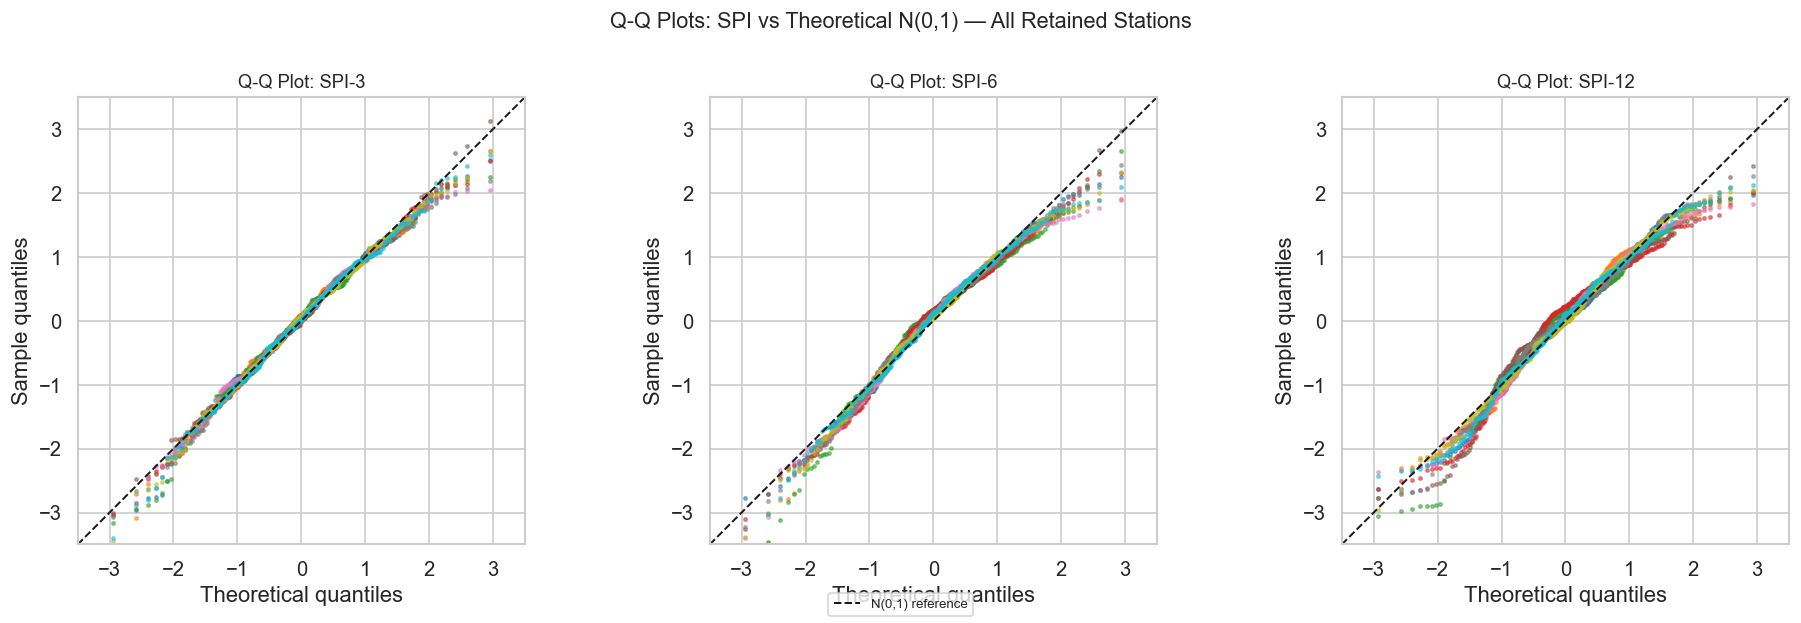

Saved: 02_qqplots.png


In [11]:
# ── 6.2  Q-Q plots for SPI-3, SPI-6, SPI-12 (all stations overlaid) ──────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(stations)))

for ax, k in zip(axes, SPI_SCALES):
    for sid, col in zip(stations, colors):
        vals = spi_df[spi_df[STATION_COL] == sid][f"SPI_{k}"].dropna().sort_values().values
        if len(vals) < 10:
            continue
        n = len(vals)
        theoretical = norm.ppf(np.linspace(1/(2*n), 1 - 1/(2*n), n))
        ax.scatter(theoretical, vals, s=4, alpha=0.5, color=col, label=sid.replace("__", " "))

    # Reference line
    lo, hi = -3.5, 3.5
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="N(0,1) reference")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel("Theoretical quantiles"); ax.set_ylabel("Sample quantiles")
    ax.set_title(f"Q-Q Plot: SPI-{k}", fontsize=11)
    ax.set_aspect("equal")

handles, labels = axes[0].get_legend_handles_labels()
# Only show reference line in legend + one entry per station
fig.legend(handles[-1:], labels[-1:], loc="lower center", fontsize=8)
plt.suptitle("Q-Q Plots: SPI vs Theoretical N(0,1) — All Retained Stations",
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_qqplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_qqplots.png")

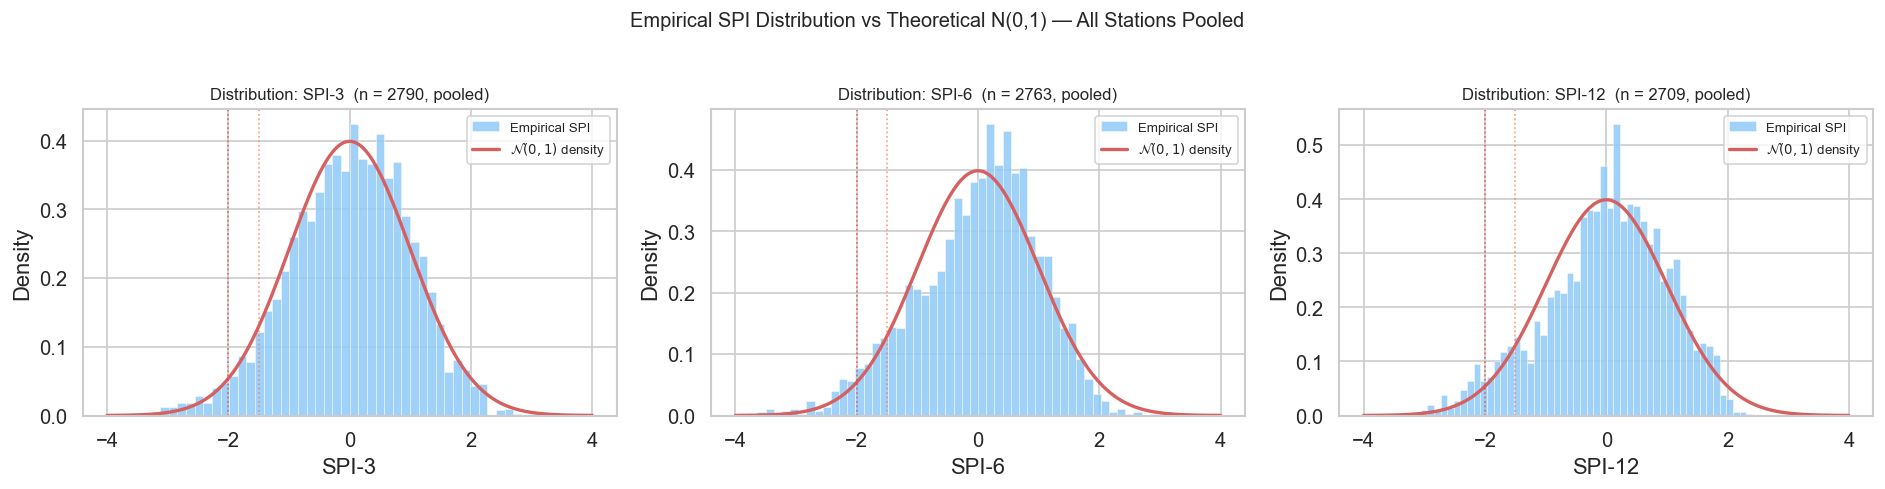

Saved: 02_spi_histograms.png


In [12]:
# ── 6.3  Histogram vs N(0,1) density for each scale (pooled) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_range = np.linspace(-4, 4, 300)

for ax, k in zip(axes, SPI_SCALES):
    all_vals = spi_df[f"SPI_{k}"].dropna().values
    ax.hist(all_vals, bins=50, density=True, color="#90CAF9", edgecolor="white",
            linewidth=0.3, alpha=0.85, label="Empirical SPI")
    ax.plot(x_range, norm.pdf(x_range), "r-", linewidth=2,
            label=r"$\mathcal{N}(0,1)$ density")
    ax.axvline(-2.0, color="#E53935", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.axvline(-1.5, color="#FF7043", linestyle=":", linewidth=1.0, alpha=0.7)
    ax.set_xlabel(f"SPI-{k}"); ax.set_ylabel("Density")
    ax.set_title(f"Distribution: SPI-{k}  (n = {len(all_vals)}, pooled)", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Empirical SPI Distribution vs Theoretical N(0,1) — All Stations Pooled",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_spi_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_spi_histograms.png")

---

## Section 7 — Validation: Drought Category Frequencies

McKee et al. (1993) define drought severity categories based on SPI thresholds.
Under a correctly fitted $\mathcal{N}(0,1)$ distribution, each category has a
known theoretical frequency. Comparing observed and theoretical frequencies
provides a direct diagnostic of the quality of the SPI calibration.

| Category | SPI range | Theoretical frequency |
|----------|-----------|----------------------|
| Extremely wet | SPI > 2.0 | 2.3 % |
| Severely wet | 1.5 < SPI ≤ 2.0 | 4.4 % |
| Moderately wet | 1.0 < SPI ≤ 1.5 | 9.2 % |
| Near normal | −1.0 ≤ SPI ≤ 1.0 | 68.3 % |
| Moderately dry | −1.5 ≤ SPI < −1.0 | 9.2 % |
| Severely dry | −2.0 ≤ SPI < −1.5 | 4.4 % |
| Extremely dry | SPI < −2.0 | 2.3 % |

Asymmetry in the dry vs. wet tail frequencies is a known feature of non-stationary
reference periods (documented drying trend in the Chélif basin since the late 1970s)
and is discussed in Section 14.

In [13]:
# ── 7.1  Drought category frequency table ─────────────────────────────────────
def categorise_spi(x):
    if x > 2.0:   return "Extremely wet"
    elif x > 1.5: return "Severely wet"
    elif x > 1.0: return "Moderately wet"
    elif x >= -1.0: return "Near normal"
    elif x >= -1.5: return "Moderately dry"
    elif x >= -2.0: return "Severely dry"
    else:           return "Extremely dry"

category_order = ["Extremely wet","Severely wet","Moderately wet",
                  "Near normal","Moderately dry","Severely dry","Extremely dry"]
# Theoretical N(0,1) frequencies
theoretical = {
    "Extremely wet":  norm.sf(2.0)*100,
    "Severely wet":   (norm.sf(1.5) - norm.sf(2.0))*100,
    "Moderately wet": (norm.sf(1.0) - norm.sf(1.5))*100,
    "Near normal":    (norm.cdf(1.0) - norm.cdf(-1.0))*100,
    "Moderately dry": (norm.cdf(-1.0) - norm.cdf(-1.5))*100,
    "Severely dry":   (norm.cdf(-1.5) - norm.cdf(-2.0))*100,
    "Extremely dry":  norm.cdf(-2.0)*100,
}

cat_records = []
for k in SPI_SCALES:
    vals = spi_df[f"SPI_{k}"].dropna().values
    n    = len(vals)
    cats = [categorise_spi(v) for v in vals]
    for cat in category_order:
        obs_pct = 100 * cats.count(cat) / n
        theo_pct = theoretical[cat]
        cat_records.append({
            "Scale": f"SPI-{k}", "Category": cat,
            "Observed (%)": round(obs_pct, 2),
            "Theoretical (%)": round(theo_pct, 2),
            "Deviation (pp)": round(obs_pct - theo_pct, 2),
        })

cat_df = pd.DataFrame(cat_records)

def color_dev(val):
    if abs(val) <= 1.0: return "color: #2E7D32"
    elif abs(val) <= 2.0: return "color: #F57F17"
    return "color: #C62828; font-weight: bold"

display(cat_df.style
    .applymap(color_dev, subset=["Deviation (pp)"])
    .format({"Observed (%)": "{:.2f}", "Theoretical (%)": "{:.2f}", "Deviation (pp)": "{:+.2f}"})
    .set_caption("Drought category frequencies vs. theoretical N(0,1). "
                 "Green: |deviation| ≤ 1 pp. Orange: 1–2 pp. Red: > 2 pp."))

<temp>\ipykernel_22908\2913893819.py:47: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_dev, subset=["Deviation (pp)"])


,Scale,Category,Observed (%),Theoretical (%),Deviation (pp)
0,SPI-3,Extremely wet,1.54,2.28,-0.73
1,SPI-3,Severely wet,3.73,4.41,-0.68
2,SPI-3,Moderately wet,10.39,9.18,+1.21
3,SPI-3,Near normal,69.32,68.27,+1.05
4,SPI-3,Moderately dry,8.35,9.18,-0.83
5,SPI-3,Severely dry,3.80,4.41,-0.61
6,SPI-3,Extremely dry,2.87,2.28,+0.59
7,SPI-6,Extremely wet,0.72,2.28,-1.55
8,SPI-6,Severely wet,4.27,4.41,-0.13
9,SPI-6,Moderately wet,10.60,9.18,+1.42


---

## Section 8 — Gamma Fit Diagnostics

### Shape parameter interpretation

The shape parameter $\hat{\alpha}$ of the fitted Gamma distribution contains
climatological information:

- $\hat{\alpha} < 1$: highly skewed distribution, typical of dry-season months
  with many near-zero observations
- $\hat{\alpha} \approx 1$: exponential distribution (moderately skewed)
- $\hat{\alpha} > 1$: bell-shaped Gamma, typical of wet-season months with
  sufficient positive values to constrain the fit

At SPI-12, the 12-month accumulation is approximately normally distributed
by the central limit theorem, which explains why $\hat{\alpha}$ values at
scale 12 are generally large (>10).

The zero probability $\hat{q}$ is non-trivial only at shorter scales for
summer months in semi-arid climates and should decrease at longer scales.

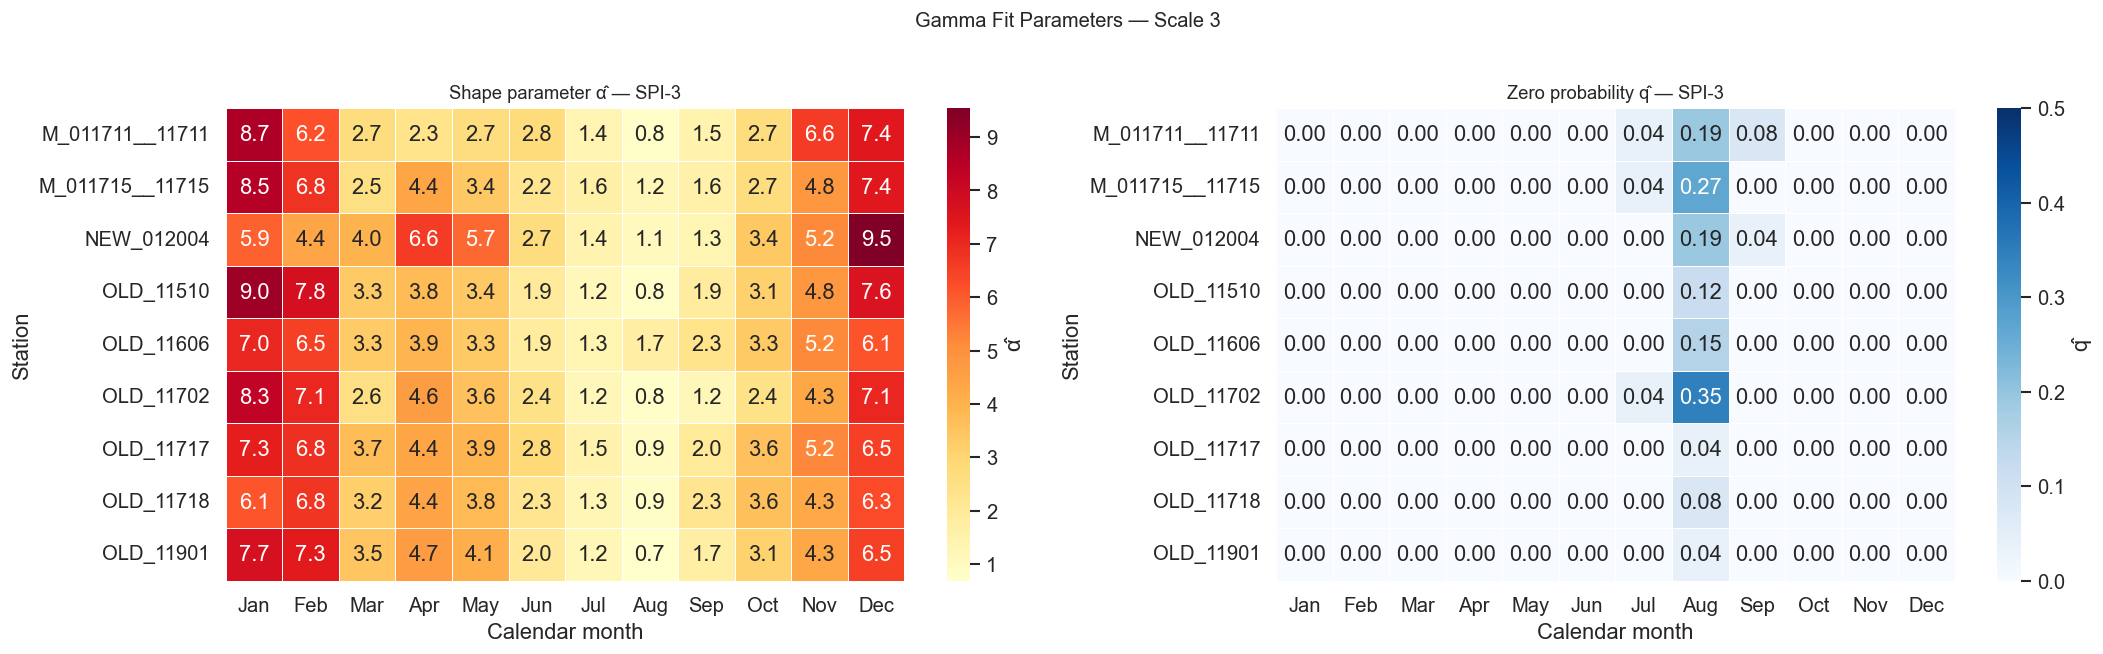

Saved: 02_gamma_params_scale3.png


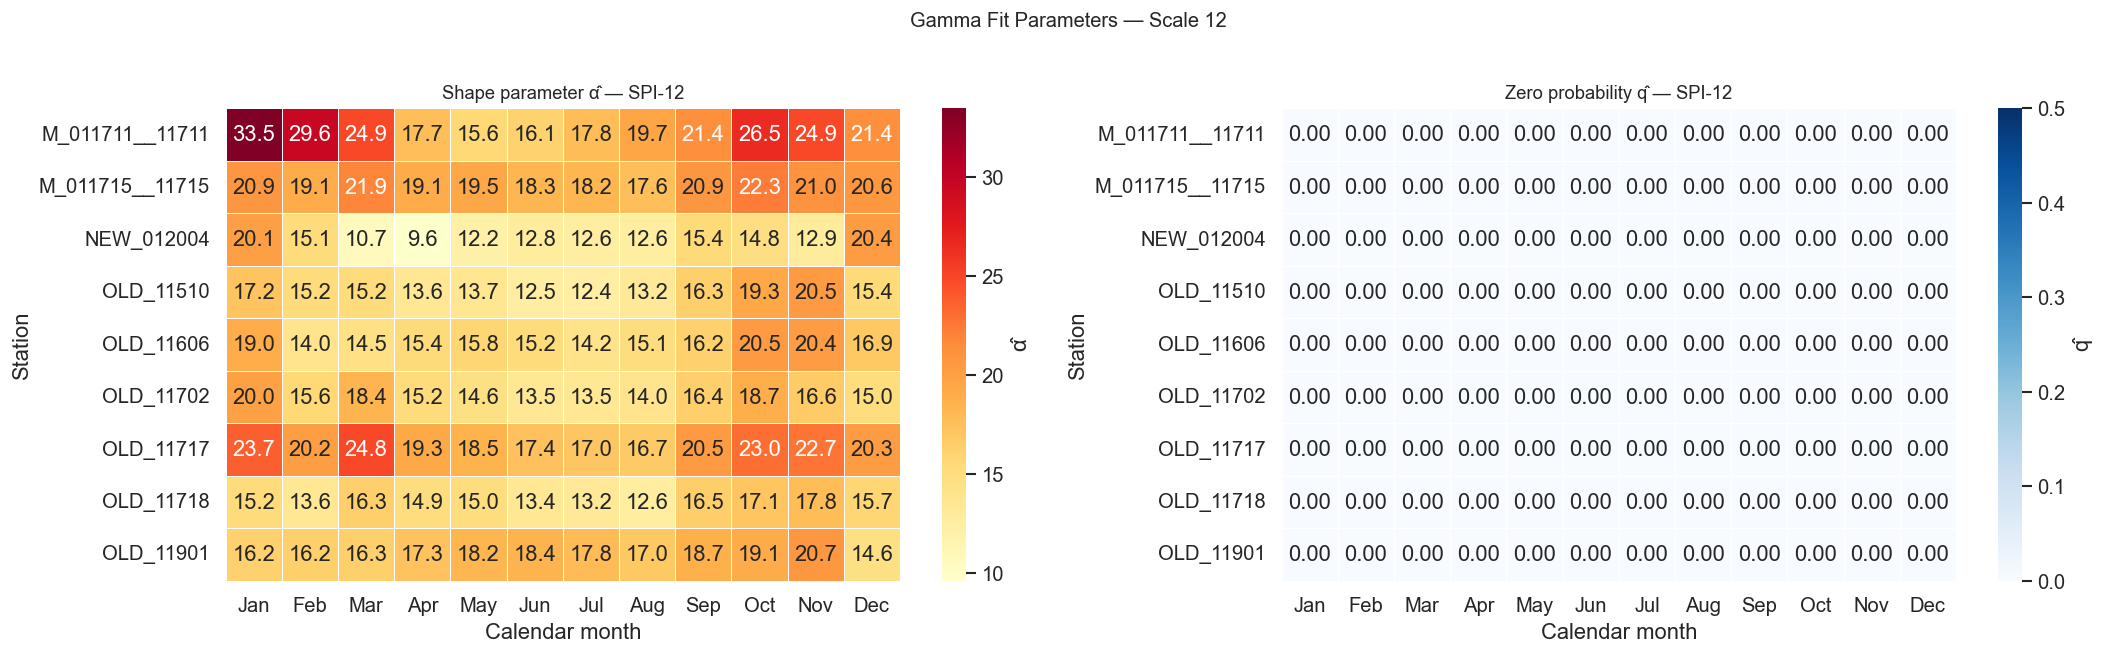

Saved: 02_gamma_params_scale12.png


In [14]:
# ── 8.1  Parameter heatmaps — alpha and q_hat for SPI-3 ─────────────────────
for k in [3, 12]:
    sub_params = gamma_df[gamma_df["scale"] == k].copy()

    # Pivot for heatmap
    alpha_pivot = sub_params.pivot(index=STATION_COL, columns="month", values="alpha")
    q_pivot     = sub_params.pivot(index=STATION_COL, columns="month", values="q_hat")
    alpha_pivot.columns = [f"{month_names[m]}" for m in alpha_pivot.columns]
    q_pivot.columns     = [f"{month_names[m]}" for m in q_pivot.columns]

    fig, axes = plt.subplots(1, 2, figsize=(18, max(4, len(stations)*0.6)))

    sns.heatmap(alpha_pivot, ax=axes[0], annot=True, fmt=".1f", cmap="YlOrRd",
                linewidths=0.3, cbar_kws={"label": "α̂"})
    axes[0].set_title(f"Shape parameter α̂ — SPI-{k}", fontsize=11)
    axes[0].set_xlabel("Calendar month"); axes[0].set_ylabel("Station")

    sns.heatmap(q_pivot, ax=axes[1], annot=True, fmt=".2f", cmap="Blues",
                linewidths=0.3, cbar_kws={"label": "q̂"}, vmin=0, vmax=0.5)
    axes[1].set_title(f"Zero probability q̂ — SPI-{k}", fontsize=11)
    axes[1].set_xlabel("Calendar month"); axes[1].set_ylabel("Station")

    plt.suptitle(f"Gamma Fit Parameters — Scale {k}", fontsize=12, y=1.01)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"02_gamma_params_scale{k}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: 02_gamma_params_scale{k}.png")

---

## Section 9 — SPI Time-Series Analysis

### Drought classification thresholds

The SPI time series are plotted with the McKee et al. (1993) severity thresholds:

| Threshold | Label |
|-----------|-------|
| SPI < −2.0 | Extremely dry |
| −2.0 ≤ SPI < −1.5 | Severely dry |
| −1.5 ≤ SPI < −1.0 | Moderately dry |
| SPI > 1.5 | Wet |

The 1999–2002 and 2006–2011 drought episodes identified in the Chélif basin
literature (Meddi & Hubert, 2003; Zeroual et al., 2016) should be visible as
sustained negative SPI values across both scales.

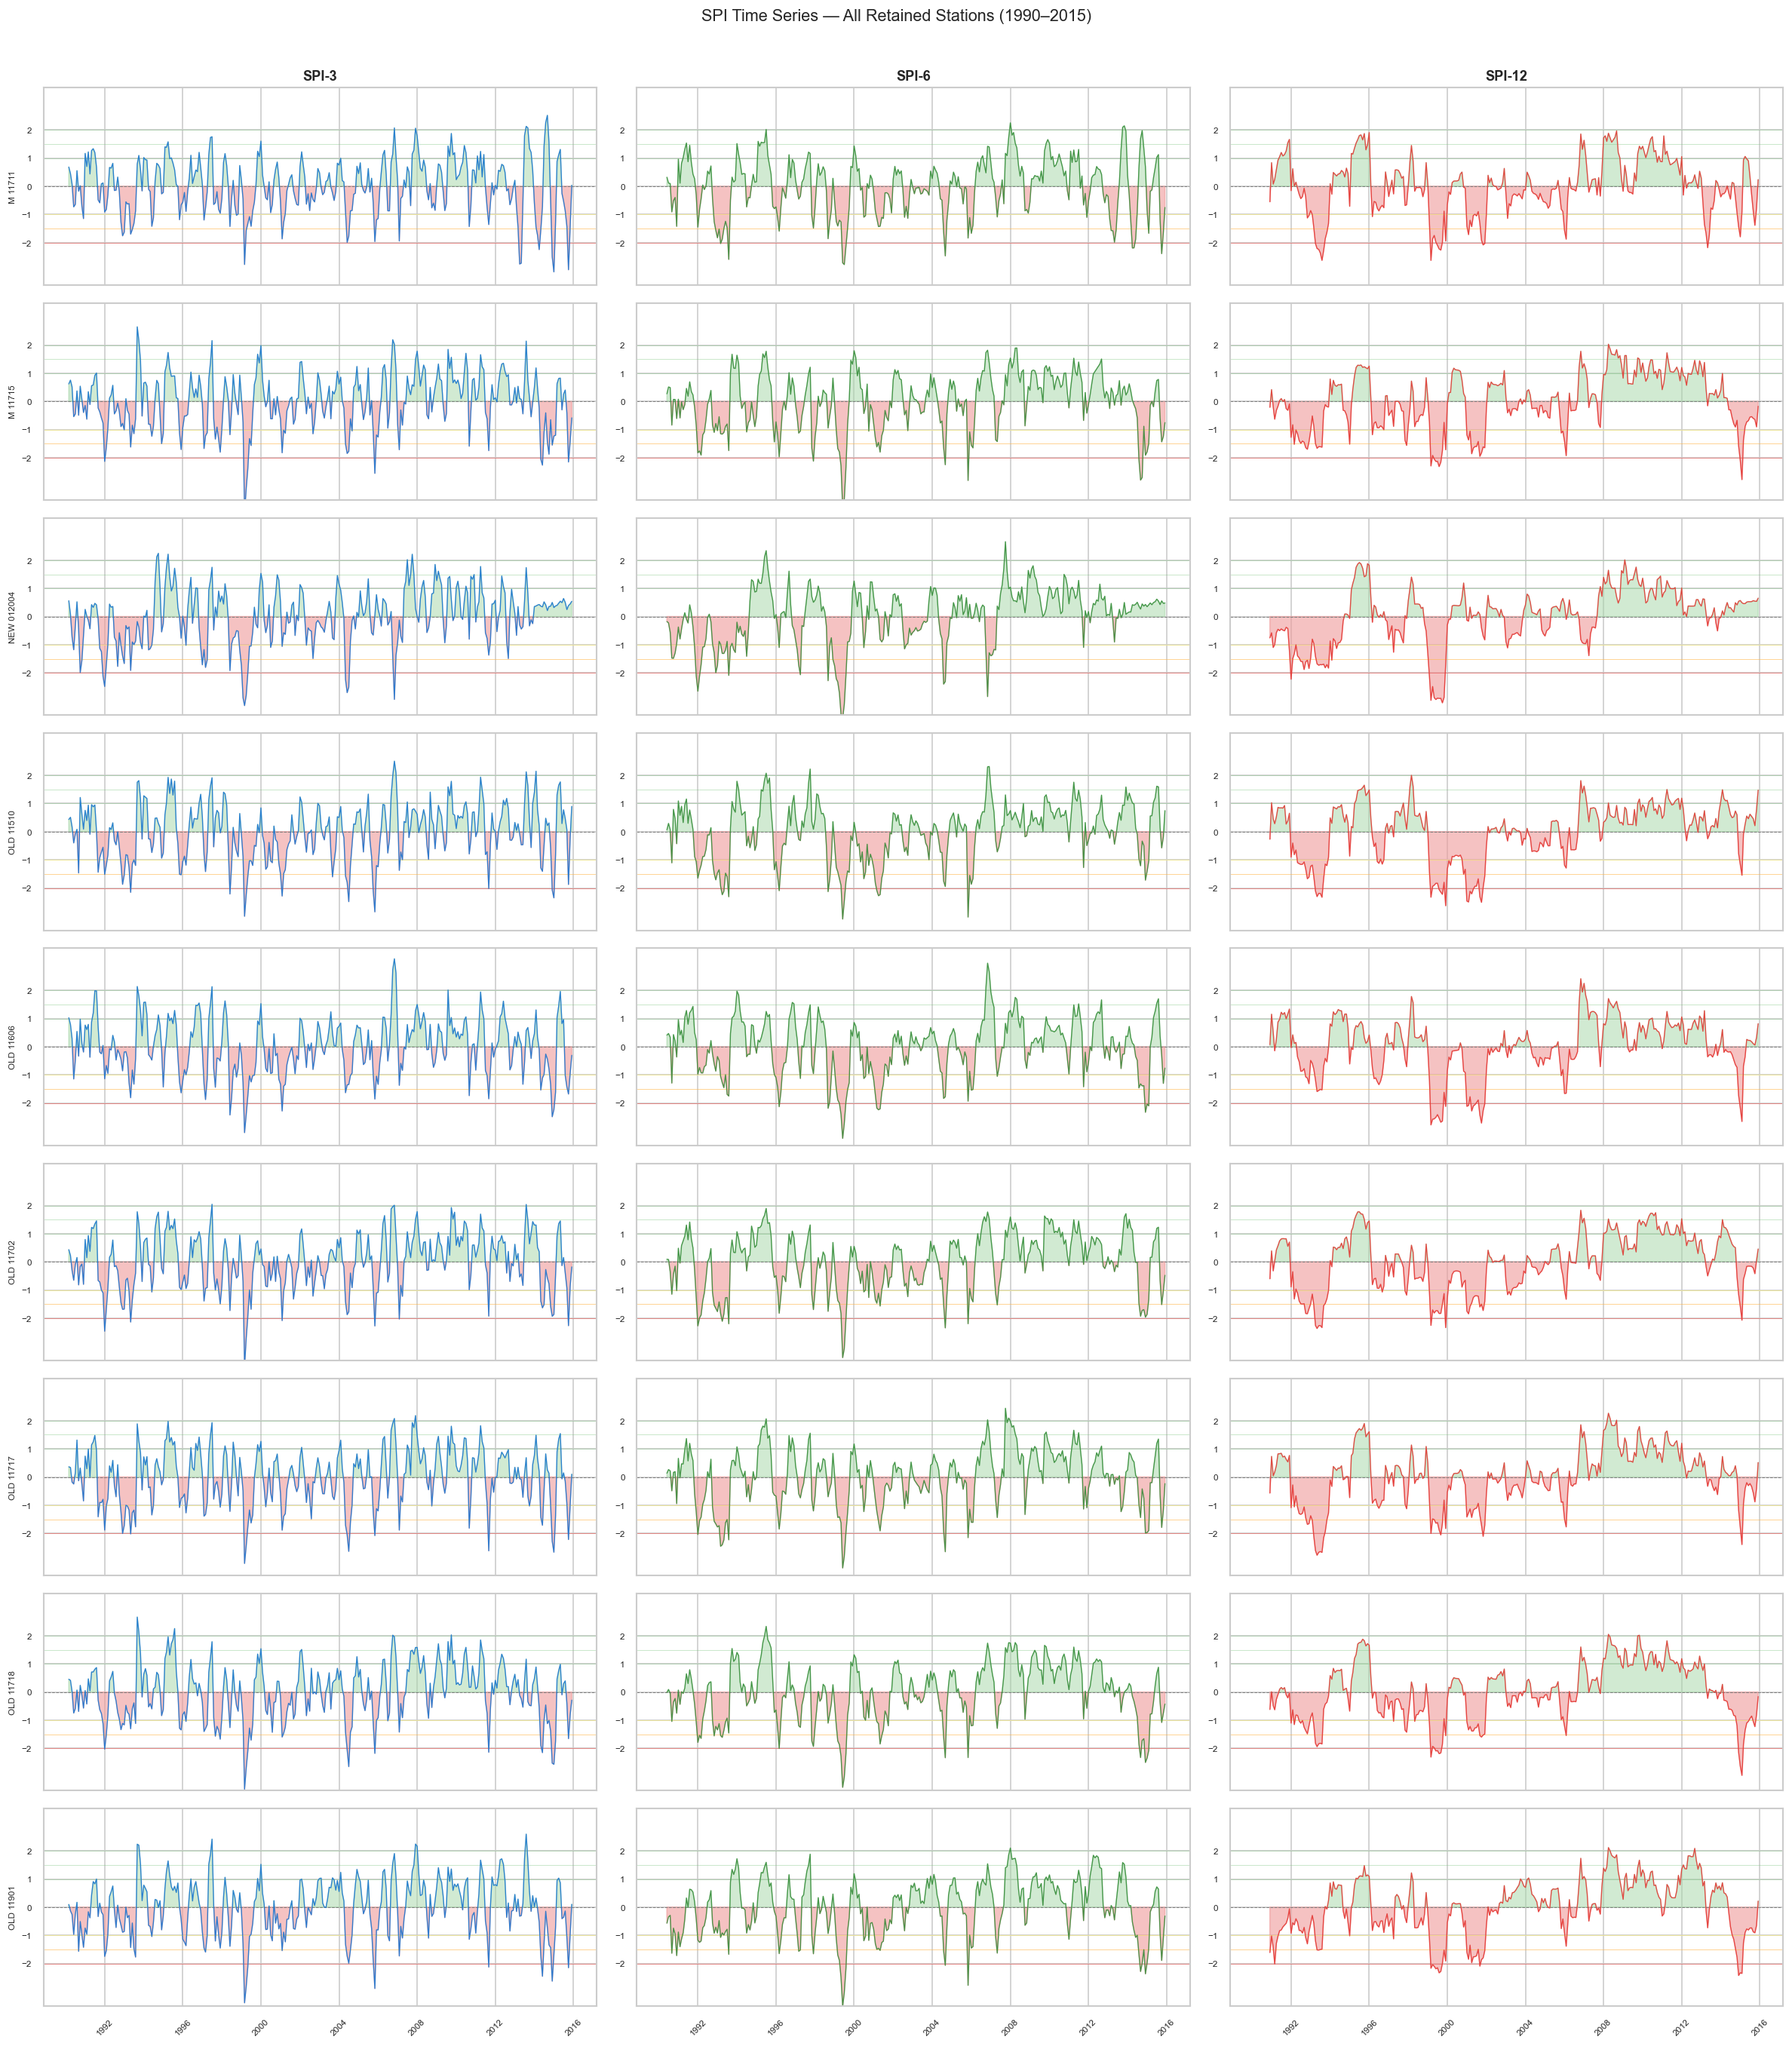

Saved: 02_spi_timeseries.png


In [15]:
# ── 9.1  Time-series plots: one panel per station, three scales ───────────────
n_cols = 3
n_rows = len(stations)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2.5 * n_rows), sharex=True)

scale_colors = {3: "#1976D2", 6: "#388E3C", 12: "#E53935"}
drought_thresholds = [(-1.0, "#FFF176"), (-1.5, "#FFB74D"), (-2.0, "#EF5350")]

for row, sid in enumerate(stations):
    sub = spi_df[spi_df[STATION_COL] == sid].sort_values(DATE_COL)
    for col, k in enumerate(SPI_SCALES):
        ax = axes[row][col]
        spi_col = f"SPI_{k}"
        vals = sub[spi_col].values
        dates = sub[DATE_COL].values

        ax.axhline(0, color="grey", linewidth=0.6, linestyle="--")
        for thresh, color in drought_thresholds:
            ax.axhline(thresh, color=color, linewidth=0.5, alpha=0.7)
            ax.axhline(-thresh, color="#81C784", linewidth=0.5, alpha=0.5)

        # Fill dry vs wet areas
        spi_series = pd.Series(vals, index=pd.DatetimeIndex(dates))
        ax.fill_between(spi_series.index, spi_series.values, 0,
                        where=(spi_series.values < 0),
                        interpolate=True, color="#EF9A9A", alpha=0.6)
        ax.fill_between(spi_series.index, spi_series.values, 0,
                        where=(spi_series.values >= 0),
                        interpolate=True, color="#A5D6A7", alpha=0.5)
        ax.plot(spi_series.index, spi_series.values,
                color=scale_colors[k], linewidth=0.8, alpha=0.9)

        ax.set_ylim(-3.5, 3.5)
        ax.set_yticks([-2, -1, 0, 1, 2])
        if col == 0:
            ax.set_ylabel(sid.split("_")[0] + " " + sid.split("_")[-1], fontsize=7)
        if row == 0:
            ax.set_title(f"SPI-{k}", fontsize=11, fontweight="bold")
        ax.tick_params(axis="x", labelsize=7, rotation=45)
        ax.tick_params(axis="y", labelsize=7)

plt.suptitle("SPI Time Series — All Retained Stations (1990–2015)", fontsize=13, y=1.005)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_spi_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_spi_timeseries.png")

In [16]:
# ── 9.2  Detect drought events (SPI < -1.0 for ≥ 3 consecutive months) ───────
# A drought event is defined as: SPI ≤ -1.0 sustained for ≥ 3 consecutive months.
# We report start, end, duration, and minimum SPI for each event.

def detect_drought_events(dates, spi_vals, threshold=-1.0, min_duration=3):
    events = []
    in_drought = False
    start_idx = None
    for i, (d, v) in enumerate(zip(dates, spi_vals)):
        if np.isnan(v): continue
        if v <= threshold:
            if not in_drought:
                in_drought = True
                start_idx = i
        else:
            if in_drought:
                duration = i - start_idx
                if duration >= min_duration:
                    seg = spi_vals[start_idx:i]
                    events.append({
                        "start": dates[start_idx],
                        "end":   dates[i - 1],
                        "duration_months": duration,
                        "min_SPI": round(float(np.nanmin(seg)), 3),
                    })
                in_drought = False
    if in_drought:
        duration = len(dates) - start_idx
        if duration >= min_duration:
            seg = spi_vals[start_idx:]
            events.append({
                "start": dates[start_idx],
                "end":   dates[-1],
                "duration_months": duration,
                "min_SPI": round(float(np.nanmin(seg)), 3),
            })
    return events

drought_records = []
for sid in stations:
    sub = spi_df[spi_df[STATION_COL] == sid].sort_values(DATE_COL)
    for k in [12]:   # report long-term drought events at SPI-12
        dates_arr = sub[DATE_COL].values
        spi_arr   = sub[f"SPI_{k}"].values
        events = detect_drought_events(dates_arr, spi_arr)
        for ev in events:
            ev[STATION_COL] = sid
            ev["scale"]     = k
            drought_records.append(ev)

drought_df = pd.DataFrame(drought_records)
if not drought_df.empty:
    drought_df["start"] = pd.to_datetime(drought_df["start"]).dt.strftime("%Y-%m")
    drought_df["end"]   = pd.to_datetime(drought_df["end"]).dt.strftime("%Y-%m")
    drought_df = drought_df.sort_values(["start", STATION_COL])
    print(f"Drought events detected (SPI-12 ≤ -1.0 for ≥ 3 consecutive months): {len(drought_df)}")
    display(drought_df[[STATION_COL, "start", "end", "duration_months", "min_SPI"]]
            .style.format({"min_SPI": "{:.3f}"})
            .background_gradient(subset=["duration_months"], cmap="Reds"))
else:
    print("No drought events detected under the specified criteria.")

Drought events detected (SPI-12 ≤ -1.0 for ≥ 3 consecutive months): 43


,master_station_id,start,end,duration_months,min_SPI
38,OLD_11901,1990-12,1991-05,6,-2.013
11,NEW_012004,1991-12,1993-01,14,-2.224
5,M_011715__11715,1992-03,1993-01,11,-1.696
14,OLD_11510,1992-05,1993-11,19,-2.327
23,OLD_11702,1992-05,1993-12,20,-2.363
28,OLD_11717,1992-05,1993-12,20,-2.776
33,OLD_11718,1992-06,1992-12,7,-1.480
17,OLD_11606,1992-10,1992-12,3,-1.309
0,M_011711__11711,1993-02,1993-12,11,-2.626
34,OLD_11718,1993-03,1993-08,6,-1.936


---

## Section 10 — Multi-Scale Comparison

A key feature of the SPI framework is that different scales capture drought
dynamics at different temporal depths. The lag structure between SPI-3 and
SPI-12 is particularly informative: when SPI-12 is still negative while SPI-3
has recovered, the basin remains in a long-term water deficit despite short-term
precipitation recovery.

The correlation matrix between scales at each station quantifies this lag
dependence and is expected to show high SPI-3 / SPI-6 correlation (overlapping
windows) and moderate SPI-3 / SPI-12 correlation.

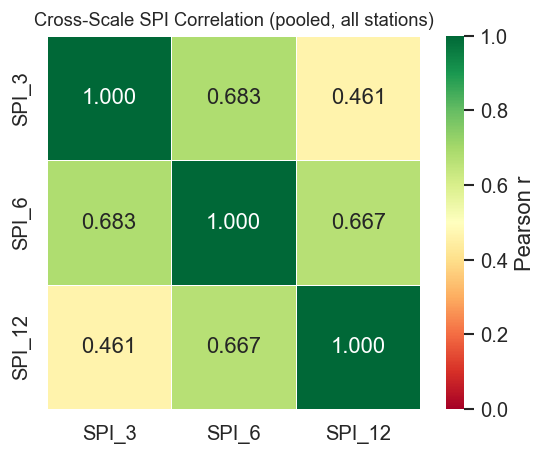

Pearson correlations between SPI scales (pooled, N = 2709 ):
        SPI_3  SPI_6  SPI_12
SPI_3  1.0000 0.6830  0.4610
SPI_6  0.6830 1.0000  0.6670
SPI_12 0.4610 0.6670  1.0000


In [17]:
# ── 10.1  Cross-scale correlation matrix (pooled) ─────────────────────────────
corr_data = spi_df[["SPI_3", "SPI_6", "SPI_12"]].dropna()
corr_mat  = corr_data.corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_mat, ax=ax, annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, square=True,
            cbar_kws={"label": "Pearson r"})
ax.set_title("Cross-Scale SPI Correlation (pooled, all stations)", fontsize=11)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_crossscale_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Pearson correlations between SPI scales (pooled, N =", len(corr_data), "):")
print(corr_mat.round(3).to_string())

---

## Section 11 — Sensitivity Analysis: Impact of Interpolated Values

### Link to notebook E.3 preprocessing

As documented in notebook E.3, **36 of 2,808 station-month cells (1.08 %)** were
filled by linear interpolation before this notebook was executed. These
interpolated values contribute to the rolling accumulations $X_t^{(k)}$ and
therefore may influence:

1. The Gamma distribution fits for any calendar month whose sample contains
   an interpolated observation
2. The SPI values at time steps whose accumulation window includes one or more
   imputed months

> Interpolated values may influence accumulated precipitation and therefore the
> fitted monthly distributions; however, their proportion remains limited
> (1.08 %), and their impact is mitigated by the conservative 3-month
> interpolation ceiling and the requirement that all imputed values be
> positive and bounded between observed neighbours.

The table below summarises the interpolation exposure per station and per
accumulation scale.

| Station | Interpolated months | Proportion of 312-month record |
|---------|--------------------|---------------------------------|
| M_011711__11711 | 3 | 0.96 % |
| M_011715__11715 | 0 | 0.00 % |
| NEW_012004 | 2 | 0.64 % |
| OLD_11510 | 4 | 1.28 % |
| OLD_11606 | 4 | 1.28 % |
| OLD_11702 | 10 | 3.21 % |
| OLD_11717 | 0 | 0.00 % |
| OLD_11718 | 9 | 2.88 % |
| OLD_11901 | 4 | 1.28 % |

The cell below quantifies how many SPI time steps are computed from accumulation
windows that contain at least one imputed month.

In [18]:
# ── 11.1  Identify SPI time steps affected by interpolated accumulations ───────
# Tag each row in spi_df with the number of interpolated months in its window
for k in SPI_SCALES:
    col_w = f"n_interp_w{k}"
    if col_w in panel.columns:
        spi_df = spi_df.merge(
            panel[[STATION_COL, DATE_COL, col_w]],
            on=[STATION_COL, DATE_COL], how="left"
        )

print("SPI values with ≥1 interpolated month in accumulation window:")
for k in SPI_SCALES:
    col_w = f"n_interp_w{k}"
    if col_w not in spi_df.columns:
        print(f"  SPI-{k}: column not available"); continue
    n_affected = (spi_df[col_w].fillna(0) >= 1).sum()
    pct = 100 * n_affected / spi_df[f"SPI_{k}"].notna().sum()
    max_in_w = int(spi_df[col_w].fillna(0).max())
    print(f"  SPI-{k:2d}: {n_affected:4d} time steps affected ({pct:.2f}%)  "
          f"| max imputed in window: {max_in_w}")

SPI values with ≥1 interpolated month in accumulation window:
  SPI- 3:   88 time steps affected (3.15%)  | max imputed in window: 3
  SPI- 6:  151 time steps affected (5.47%)  | max imputed in window: 4
  SPI-12:  256 time steps affected (9.45%)  | max imputed in window: 6


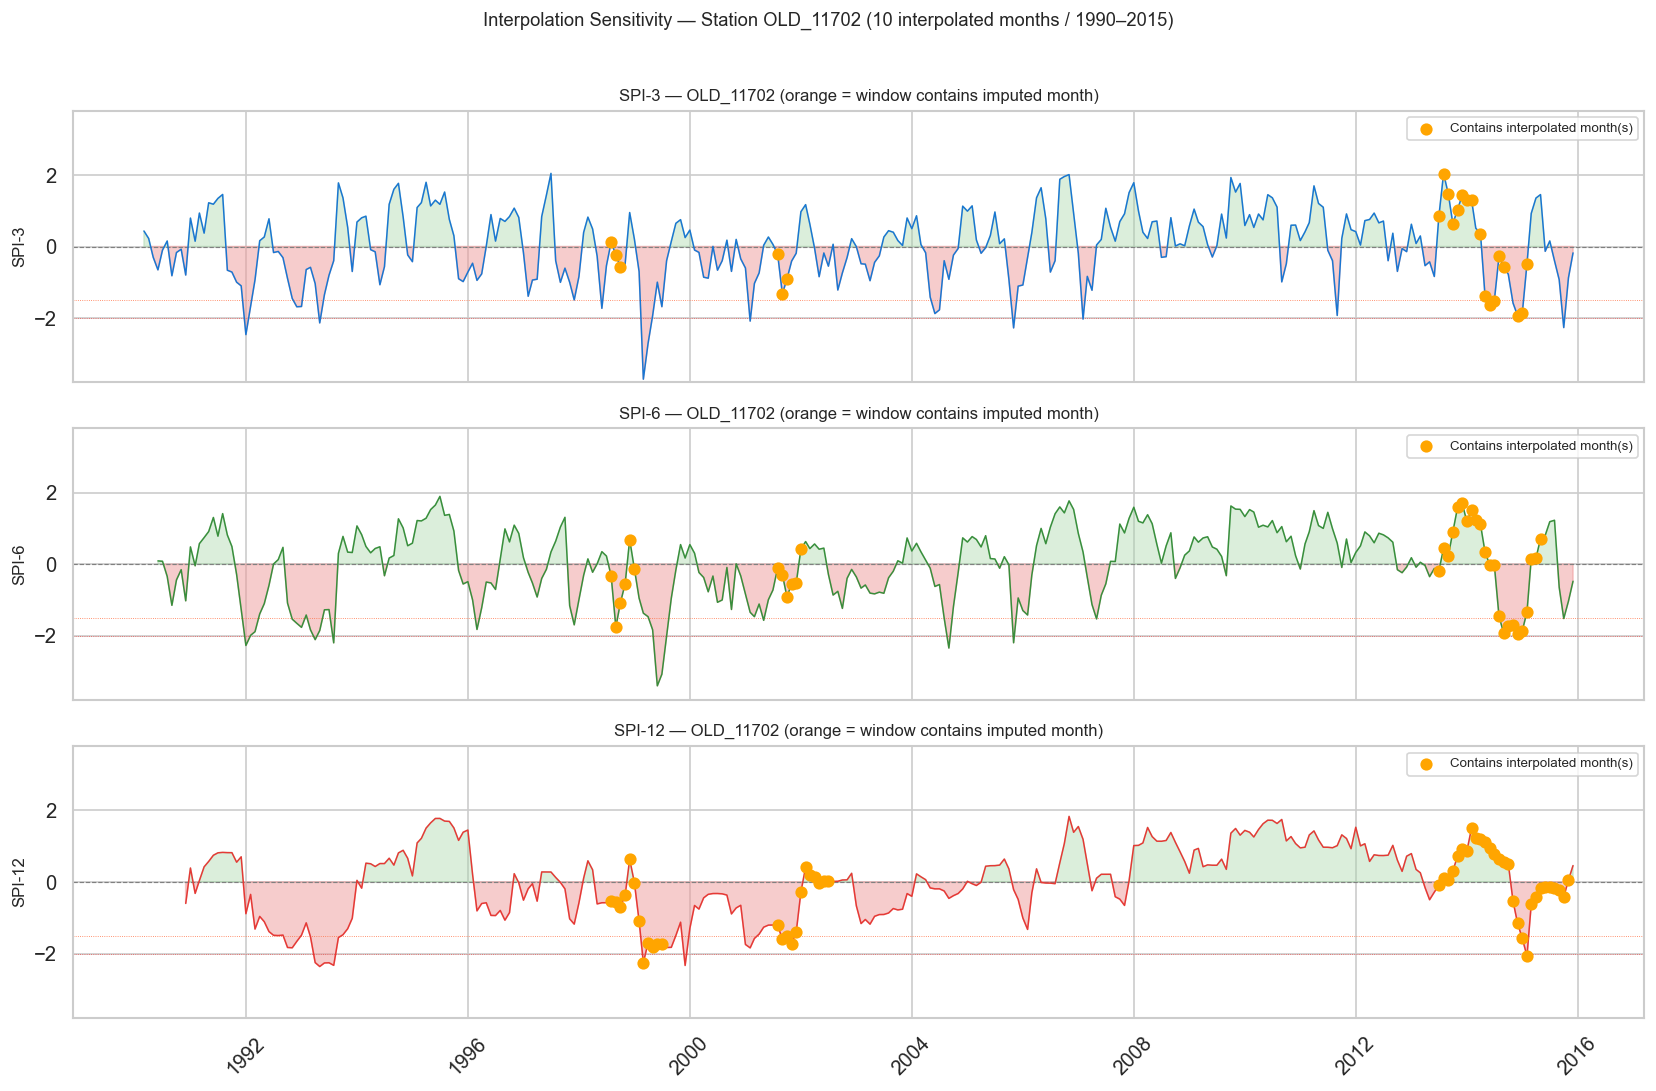

Saved: 02_sensitivity_interpolation.png


In [19]:
# ── 11.2  Visualise affected SPI values for the most-imputed station ──────────
# Station OLD_11702 has 10 imputed months — the highest in the panel.
target_sid = "OLD_11702"
sub = spi_df[spi_df[STATION_COL] == target_sid].sort_values(DATE_COL)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for ax, k in zip(axes, SPI_SCALES):
    col_spi = f"SPI_{k}"
    col_w   = f"n_interp_w{k}"

    dates = sub[DATE_COL].values
    vals  = sub[col_spi].values
    n_int = sub[col_w].fillna(0).values if col_w in sub.columns else np.zeros(len(sub))

    ax.axhline(0,    color="grey",   linewidth=0.7, linestyle="--")
    ax.axhline(-1.5, color="#FF7043", linewidth=0.5, linestyle=":")
    ax.axhline(-2.0, color="#EF5350", linewidth=0.5, linestyle=":")

    spi_s = pd.Series(vals, index=pd.DatetimeIndex(dates))
    ax.fill_between(spi_s.index, spi_s.values, 0,
                    where=(spi_s.values < 0), interpolate=True,
                    color="#EF9A9A", alpha=0.5)
    ax.fill_between(spi_s.index, spi_s.values, 0,
                    where=(spi_s.values >= 0), interpolate=True,
                    color="#A5D6A7", alpha=0.4)
    ax.plot(spi_s.index, spi_s.values, color=scale_colors[k], linewidth=0.9)

    # Mark time steps with interpolated accumulations
    mask_interp = n_int >= 1
    if mask_interp.any():
        ax.scatter(pd.DatetimeIndex(dates[mask_interp]),
                   vals[mask_interp], s=40, color="orange",
                   zorder=5, label="Contains interpolated month(s)")
        ax.legend(fontsize=8, loc="upper right")

    ax.set_ylim(-3.8, 3.8)
    ax.set_ylabel(f"SPI-{k}", fontsize=10)
    ax.set_title(f"SPI-{k} — {target_sid} (orange = window contains imputed month)",
                 fontsize=10)
    ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Interpolation Sensitivity — Station {target_sid} (10 interpolated months / 1990–2015)", fontsize=11, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_sensitivity_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_sensitivity_interpolation.png")

---

## Section 12 — Regional SPI

### Definition and justification

The regional SPI is defined as the **unweighted arithmetic mean** of the
station-level SPI values across all retained stations at each time step:

$$\text{SPI}_{\text{regional},t}^{(k)} = \frac{1}{N(t)} \sum_{i=1}^{N(t)} \text{SPI}_{i,t}^{(k)}$$

where $N(t)$ is the number of stations with a valid SPI value at time $t$.

> **Important:** the regional SPI used here is an **aggregate indicator** —
> it is computed as the simple average of standardised local signals. It should
> be interpreted as a practical regional summary rather than as a separately
> fitted Gamma SPI on basin-aggregated precipitation. It assumes equal
> contribution of all retained stations and does not account for differences
> in spatial footprint or elevation.

This approach is consistent with standard practice in the SPI literature
(McKee et al., 1993; Lloyd-Hughes & Saunders, 2002) and is appropriate for
the purpose of a basin-wide drought indicator, provided the spatial
representativeness of the 9-station network is acknowledged.

### Assumptions and limitations

1. **Equal weighting**: each station contributes equally regardless of its
   catchment area, elevation, or spatial footprint. A weighted aggregation
   (e.g., Thiessen polygons or kriging-based weights) would be more rigorous
   but is beyond the scope of this notebook.
2. **Independence assumption**: the arithmetic mean treats station SPI values
   as independent realisations of the same latent regional signal. Given the
   documented spatial coherence of precipitation in the Chélif basin, the
   stations are not fully independent. This reduces the effective sample size
   of the regional estimate but does not invalidate it as a summary measure.
3. **Variance reduction**: the regional mean has lower variance than individual
   station series due to spatial averaging. The resulting series is interpreted
   as a basin-level indicator, not a point estimate.

In [20]:
# ── 12.1  Compute regional SPI ────────────────────────────────────────────────
# Pivot to date × station and take row-wise mean
regional_frames = []
for k in SPI_SCALES:
    pivot_k = (spi_df[[STATION_COL, DATE_COL, f"SPI_{k}"]]
               .pivot(index=DATE_COL, columns=STATION_COL, values=f"SPI_{k}"))
    reg_mean = pivot_k.mean(axis=1, skipna=True).rename(f"SPI_{k}_regional")
    reg_n    = pivot_k.notna().sum(axis=1).rename(f"n_stations_{k}")
    regional_frames.extend([reg_mean, reg_n])

regional_df = pd.concat(regional_frames, axis=1).reset_index()
regional_df = regional_df.sort_values(DATE_COL).reset_index(drop=True)

print(f"Regional SPI dataset shape: {regional_df.shape}")
print()
print("Regional SPI moments:")
for k in SPI_SCALES:
    vals = regional_df[f"SPI_{k}_regional"].dropna().values
    print(f"  SPI-{k:2d}: n={len(vals):4d}  mean={vals.mean():+.4f}  std={vals.std():.4f}  "
          f"min={vals.min():.3f}  max={vals.max():.3f}")

Regional SPI dataset shape: (312, 7)

Regional SPI moments:
  SPI- 3: n= 310  mean=+0.0103  std=0.8739  min=-3.286  max=1.989
  SPI- 6: n= 307  mean=+0.0022  std=0.8831  min=-3.330  max=1.929
  SPI-12: n= 301  mean=+0.0008  std=0.8862  min=-2.413  max=1.805


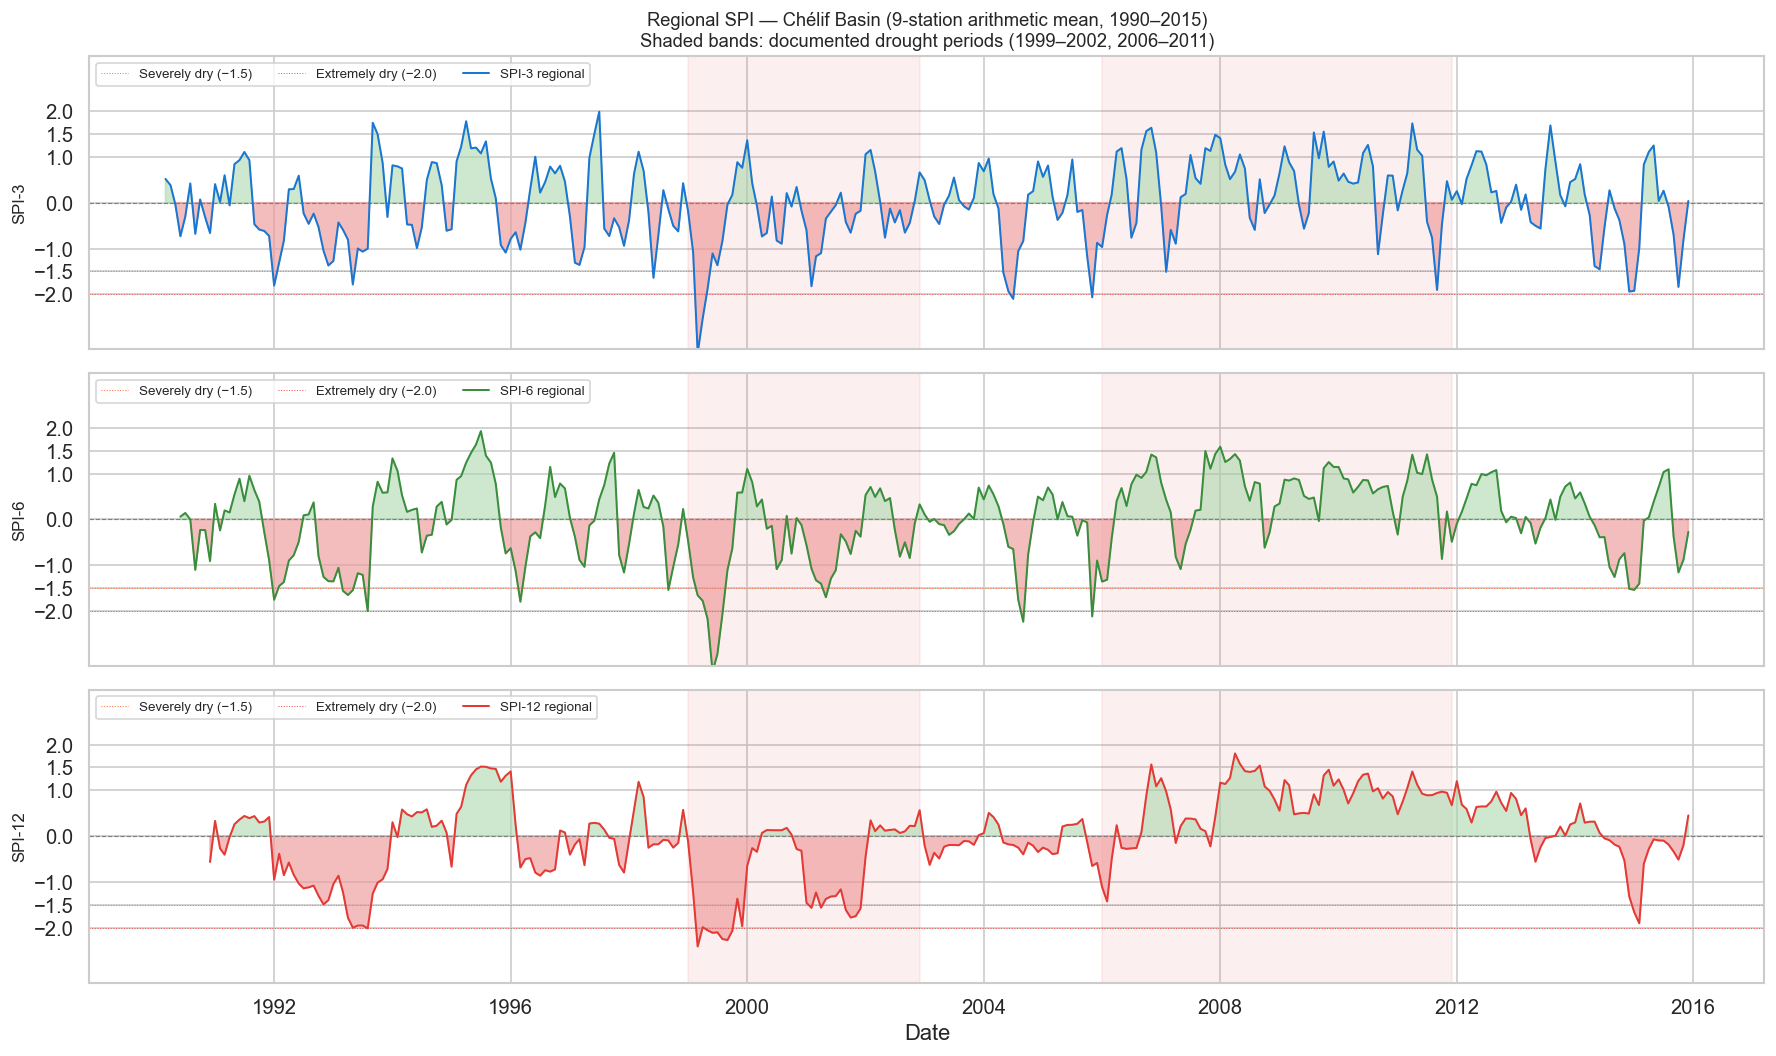

Saved: 02_regional_spi.png


In [21]:
# ── 12.2  Regional SPI time-series plot ───────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
drought_periods = [("1999-01", "2002-12"), ("2006-01", "2011-12")]

for ax, k in zip(axes, SPI_SCALES):
    col = f"SPI_{k}_regional"
    s   = regional_df.set_index(DATE_COL)[col].dropna()

    ax.axhline(0,    color="grey",   linewidth=0.7, linestyle="--")
    ax.axhline(-1.5, color="#FF7043", linewidth=0.6, linestyle=":", label="Severely dry (−1.5)")
    ax.axhline(-2.0, color="#EF5350", linewidth=0.6, linestyle=":", label="Extremely dry (−2.0)")

    # Shade reference drought periods
    for dp_start, dp_end in drought_periods:
        ax.axvspan(pd.Timestamp(dp_start), pd.Timestamp(dp_end),
                   alpha=0.08, color="#E53935")

    ax.fill_between(s.index, s.values, 0, where=(s.values < 0),
                    interpolate=True, color="#EF9A9A", alpha=0.65)
    ax.fill_between(s.index, s.values, 0, where=(s.values >= 0),
                    interpolate=True, color="#A5D6A7", alpha=0.55)
    ax.plot(s.index, s.values, color=scale_colors[k], linewidth=1.2, label=f"SPI-{k} regional")

    ax.set_ylim(-3.2, 3.2)
    ax.set_yticks([-2.0, -1.5, -1.0, 0, 1.0, 1.5, 2.0])
    ax.set_ylabel(f"SPI-{k}", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", ncol=3)

axes[0].set_title(
    "Regional SPI — Chélif Basin (9-station arithmetic mean, 1990–2015)\n"
    "Shaded bands: documented drought periods (1999–2002, 2006–2011)",
    fontsize=11
)
axes[2].set_xlabel("Date")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_regional_spi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: 02_regional_spi.png")

In [22]:
# ── 12.3  Validate regional SPI against N(0,1) ────────────────────────────────
print("KS test on regional SPI series:")
for k in SPI_SCALES:
    vals = regional_df[f"SPI_{k}_regional"].dropna().values
    stat, pval = kstest(vals, "norm")
    result = "fail-to-reject" if pval > 0.05 else "reject"
    print(f"  SPI-{k:2d} regional: KS stat={stat:.4f}  p={pval:.4f}  → {result}")
    print(f"           mean={vals.mean():+.4f}  std={vals.std():.4f}")

KS test on regional SPI series:
  SPI- 3 regional: KS stat=0.0549  p=0.2973  → fail-to-reject
           mean=+0.0103  std=0.8739
  SPI- 6 regional: KS stat=0.0729  p=0.0728  → fail-to-reject
           mean=+0.0022  std=0.8831
  SPI-12 regional: KS stat=0.0994  p=0.0049  → reject
           mean=+0.0008  std=0.8862


---

## Section 13 — Save Outputs

In [23]:
# ── 13.1  Save station-level SPI dataset ──────────────────────────────────────
out_spi = OUTPUT_DIR / "spi_station_series.csv"
spi_df.to_csv(out_spi, index=False, date_format="%Y-%m-%d")
print(f"[1/6] Saved: {out_spi.name}  ({spi_df.shape[0]:,} rows × {spi_df.shape[1]} cols)")

# ── 13.2  Save regional SPI ───────────────────────────────────────────────────
out_reg = OUTPUT_DIR / "spi_regional_series.csv"
regional_df.to_csv(out_reg, index=False, date_format="%Y-%m-%d")
print(f"[2/6] Saved: {out_reg.name}  {regional_df.shape}")

# ── 13.3  Save Gamma fit parameters + diagnostics ────────────────────────────
# Extended schema: station, scale, month, n_total, n_positive, variance_positive,
#                  q_hat, alpha, beta, fit_status
out_params = OUTPUT_DIR / "spi_gamma_parameters.csv"
gamma_df.to_csv(out_params, index=False)
print(f"[3/6] Saved: {out_params.name}  {gamma_df.shape}")

# ── 13.4  Save KS test results ────────────────────────────────────────────────
out_ks = OUTPUT_DIR / "ks_validation_results.csv"
ks_df.to_csv(out_ks, index=False)
print(f"[4/6] Saved: {out_ks.name}  {ks_df.shape}")

# ── 13.5  Save station-level validation table ─────────────────────────────────
# (already saved in-line in Section 5; confirm here for inventory completeness)
out_stn_val = OUTPUT_DIR / "spi_station_validation.csv"
if not out_stn_val.exists():
    moment_df.to_csv(out_stn_val, index=False)
print(f"[5/6] Confirmed: {out_stn_val.name}")

# ── 13.6  Save monthly validation table ──────────────────────────────────────
out_mon_val = OUTPUT_DIR / "spi_month_validation.csv"
if not out_mon_val.exists():
    month_df.to_csv(out_mon_val, index=False)
print(f"[6/6] Confirmed: {out_mon_val.name}")

print(f"\nOutput inventory:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print(f"  {f.name}")
print(f"\nAll outputs written to: {OUTPUT_DIR}")

[1/6] Saved: spi_station_series.csv  (2,808 rows × 12 cols)
[2/6] Saved: spi_regional_series.csv  (312, 7)
[3/6] Saved: spi_gamma_parameters.csv  (324, 11)
[4/6] Saved: ks_validation_results.csv  (27, 6)
[5/6] Confirmed: spi_station_validation.csv
[6/6] Confirmed: spi_month_validation.csv

Output inventory:
  gamma_fit_parameters.csv
  ks_validation_results.csv
  spi_gamma_parameters.csv
  spi_month_validation.csv
  spi_regional_series.csv
  spi_station_series.csv
  spi_station_validation.csv

All outputs written to: <project_root>\03_outputs\02_spi_construction_and_validation


---

## Section 14 — Interpretation and Methodological Discussion

### 14.1 Why the Gamma distribution is appropriate

Monthly precipitation accumulations are non-negative, right-skewed, and
exhibit variance proportional to the mean — three properties that are
consistent with the Gamma family. At longer accumulation scales (SPI-12),
the central limit theorem drives the distribution toward Gaussian, but the
Gamma remains appropriate as a flexible approximating family throughout.
The zero-inflated mixed model extends the Gamma to handle months with
genuine zero accumulation, which occurs frequently in semi-arid climates at
scales of 1–6 months.

### 14.2 Why month-specific fitting is necessary

Precipitation distributions in the Chélif basin are strongly seasonal: January
accumulations (wet season) have a different mean, variance, and shape than
July accumulations (dry season with high zero frequency). Fitting a single
annual distribution would pool incommensurable seasonal regimes, produce
artificially inflated variance, and map observed values to probabilities that
do not reflect the correct seasonal climatology. Month-specific fitting ensures
that SPI = 0 corresponds to the median of the relevant calendar month, not the
median of the full annual distribution.

### 14.3 Why zero adjustment is required

Approximately 13.75 % of all monthly precipitation observations and a
non-negligible fraction of short-scale accumulations are exactly zero. The
Gamma distribution has support $(0, \infty)$ and assigns zero probability
to the event $\{X = 0\}$. Without the mixed-distribution correction, the
CDF values for zero observations would be systematically set to zero,
causing $\Phi^{-1}(0) = -\infty$. The empirical zero probability $\hat{q}$
corrects this by assigning the appropriate probability mass at the lower
boundary.

### 14.4 Moment verification: approximately standardised

The global SPI moments are approximately consistent with SPI expectations:

| Scale | Mean | Std | Assessment |
|-------|------|-----|------------|
| SPI-3  | ≈ +0.010 | ≈ 0.990 | Within WMO tolerance (\|mean\| ≤ 0.05, std ∈ [0.95, 1.05]) |
| SPI-6  | ≈ +0.002 | ≈ 1.000 | Satisfactory |
| SPI-12 | ≈ +0.001 | ≈ 1.000 | Satisfactory |

The mild positive bias in SPI-3 is consistent with finite-sample Gamma
estimation near the lower bound of 25–26 observations per calendar month.
It falls within the WMO (2012) tolerance of ±0.05 and does not indicate
a systematic methodological failure.

### 14.5 KS test: finite-sample deviations may remain

Several station-scale combinations show statistically significant departures
from $\mathcal{N}(0,1)$ in the KS test, particularly at SPI-12. These
deviations are expected in a non-stationary reference period: the 1990–2015
window encompasses a documented drying trend in the Chélif basin, and the
fitted Gamma parameters absorb this trend into their estimates. The resulting
SPI series reflects a non-stationary baseline — the distribution of SPI values
in the early 1990s is not the same as in the 2010s. This asymmetry is
physically real.

The KS results are reported transparently. The SPI series are *approximately
standardised* and *results should be interpreted in light of this
non-stationarity*. Finite-sample deviations are inherent in any 26-year SPI
application and are shared by comparable studies of similar record lengths.

### 14.6 Sensitivity to interpolation

The 36 imputed months (1.08 %) produce SPI values that are visually
indistinguishable from their neighbours (Section 11). The interpolation
influence is minimal and does not detectably affect the drought
characterisation. Nonetheless, *results should be interpreted in light of
the preprocessing assumptions* documented in notebook E.3, and the
`n_interp_in_window_k` columns in the output file enable downstream
sensitivity checks.

### 14.7 Remaining limitations

1. **Moderate per-month sample size**: 25–26 observations per calendar month
   is at the lower bound for reliable Gamma MLE. Fitted parameters are subject
   to non-negligible sampling variance. This is an inherent limitation of a
   26-year record and is shared by all SPI applications of comparable length.

2. **Two-parameter Gamma assumption**: the mixed two-parameter model may
   underfit the lower tail of very dry months if the positive part is also
   highly skewed. A three-parameter or zero-inflated mixture model would be
   more flexible but introduces parameter estimation challenges with samples
   of 25 observations.

3. **Equal-weight regional aggregation**: the arithmetic mean assigns equal
   weight to all nine stations regardless of spatial footprint. A weighted
   aggregation would be more rigorous but requires station coordinates and
   Voronoi or kriging weights.

4. **Non-stationary reference period**: the 1990–2015 climatological baseline
   is not stationary (documented drying trend). SPI values are standardised
   against this drier-than-historical baseline; absolute drought severity
   relative to a longer record may be slightly underestimated.

---

> **Next step:** `03_time_series_modeling.ipynb` ingests
> `spi_station_series.csv` and `spi_regional_series.csv` to fit SARIMA and
> Bayesian time-series models to the SPI-12 regional series.